<a href="https://colab.research.google.com/github/HST0077/HYOTC/blob/main/HY_OTC_Frontier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPU가 존재하는지 확인

In [20]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시 갱신
fm._load_fontmanager(try_read_cache=False)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

Resolved font_name: NanumGothic


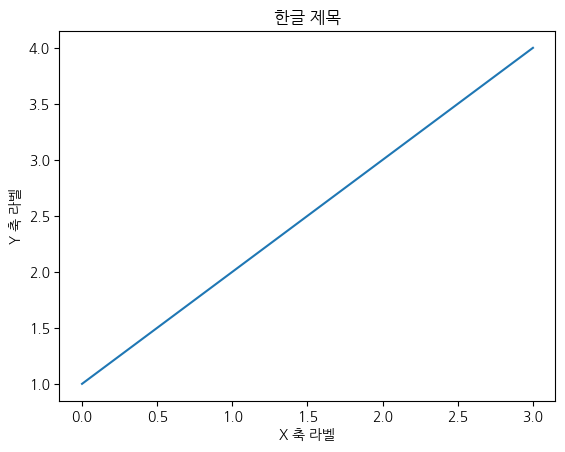

In [22]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1) 폰트 파일 경로 (존재하는 걸로 확인됨)
FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 2) Matplotlib 폰트 매니저에 "등록" (중요)
fm.fontManager.addfont(FONT_PATH)

# 3) 등록된 폰트의 정확한 패밀리 이름을 파일에서 다시 읽어옴
font_name = fm.FontProperties(fname=FONT_PATH).get_name()
print("Resolved font_name:", font_name)

# 4) rcParams 리셋 후 적용
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# 5) 테스트
plt.plot([1,2,3,4])
plt.title("한글 제목")
plt.xlabel("X 축 라벨")
plt.ylabel("Y 축 라벨")
plt.show()

In [4]:
# backend.py 내용
_XP = None
_CAPABILITY = None
def init_backend():
    global _XP, _CAPABILITY
    if _XP is not None:
        return _XP
    try:
        import cupy as cp
        _ = cp.array(1.0) + 1
        _XP = cp
        _CAPABILITY = "gpu"
    except Exception:
        import numpy as np
        _XP = np
        _CAPABILITY = "cpu"
    return _XP
def get_backend():
    global _XP, _CAPABILITY
    if _XP is None:
        init_backend()
    return _XP
def _to_float(x):
    if hasattr(x, "get"):
        return float(x.get())
    return float(x)

# Plain Vanilla

In [2]:
# BSM 공식
"""
Black-Scholes 해석 공식 (배당수익률 q 적용)
Plain/BSM_MC.py의 MC_Call, MC_Greeks와 동일 계약·Greeks 정의
"""

from math import log, sqrt, exp
from scipy.stats import norm


def _d1_d2(S, K, T, r, q, sigma):
    if T <= 0:
        return 0.0, 0.0
    sqrtT = sqrt(T)
    d1 = (log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return d1, d2


def BSM(S, K, T, r, q, sigma, option="call"):
    """
    European 옵션 해석 가격 (연속 배당수익률 q).
    option: "call" | "put"
    """
    opt = option.lower().strip()
    if opt not in ("call", "put"):
        raise ValueError('option must be "call" or "put"')
    if T <= 0:
        return max(S - K, 0.0) if opt == "call" else max(K - S, 0.0)
    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    if opt == "call":
        return S * exp(-q * T) * norm.cdf(d1) - K * exp(-r * T) * norm.cdf(d2)
    return K * exp(-r * T) * norm.cdf(-d2) - S * exp(-q * T) * norm.cdf(-d1)


# 하위호환
BSM_Call = lambda S, K, T, r, q, sigma: BSM(S, K, T, r, q, sigma, "call")
BSM_Put = lambda S, K, T, r, q, sigma: BSM(S, K, T, r, q, sigma, "put")


def BSM_Greeks(S, K, T, r, q, sigma, option="call"):
    """
    해석적 Greeks.
    option: "call" | "put"
    반환: Price, Delta(Δ), Gamma(Γ), Theta(1day), Vega(1%), Rho(1bp)
    """
    opt = option.lower().strip()
    if opt not in ("call", "put"):
        raise ValueError('option must be "call" or "put"')

    if T <= 0:
        intrinsic = max(S - K, 0.0) if opt == "call" else max(K - S, 0.0)
        delta_int = (1.0 if S > K else 0.0) if opt == "call" else (-1.0 if S < K else 0.0)
        return {
            "Price": intrinsic,
            "Delta (Δ)": delta_int,
            "Gamma (Γ)": 0.0,
            "Theta (Θ)": 0.0,
            "Vega (V)": 0.0,
            "Rho (ρ)": 0.0,
        }

    d1, d2 = _d1_d2(S, K, T, r, q, sigma)
    sqrtT = sqrt(T)
    n_d1 = norm.pdf(d1)

    # Price
    price = BSM(S, K, T, r, q, sigma, opt)
    if opt == "call":
        Delta = exp(-q * T) * norm.cdf(d1)
        Rho = 0.0001 * (T * K * exp(-r * T) * norm.cdf(d2))
    else:
        Delta = -exp(-q * T) * norm.cdf(-d1)  # = exp(-q*T)*(N(d1)-1)
        Rho = 0.0001 * (-T * K * exp(-r * T) * norm.cdf(-d2))

    # Gamma (Γ): Call과 Put 동일
    Gamma = exp(-q * T) * n_d1 / (S * sigma * sqrtT) if sqrtT > 0 and sigma > 0 else 0.0

    # Vega: Call과 Put 동일
    Vega = 0.01 * S * exp(-q * T) * sqrtT * n_d1

    # Theta (1day)
    eps_t = 1.0 / 365.0
    T_eps = max(T - eps_t, 1e-10)
    Theta = BSM(S, K, T_eps, r, q, sigma, opt) - price

    return {
        "Price": float(price),
        "Delta (Δ)": float(Delta),
        "Gamma (Γ)": float(Gamma),
        "Theta (Θ)": float(Theta),
        "Vega (V)": float(Vega),
        "Rho (ρ)": float(Rho),
    }


In [3]:
BSM_Greeks(100, 100, 1, 0.05, 0, 0.3,'call')

{'Price': 14.231254785985819,
 'Delta (Δ)': 0.6242517279060125,
 'Gamma (Γ)': 0.012647764437231512,
 'Theta (Θ)': -0.022207200555286022,
 'Vega (V)': 0.37943293311694537,
 'Rho (ρ)': 0.004819391800461543}

In [4]:
# MC 함수
def MC(S, K, T, r, q, sigma, option="call", n_sim=100000):
    """
    European 옵션 Monte Carlo 가격.
    option: "call" | "put"
    """
    opt = option.lower().strip()
    if opt not in ("call", "put"):
        raise ValueError('option must be "call" or "put"')

    xp = get_backend()
    xp.random.seed(11)
    Z = xp.random.randn(n_sim)
    ST = S * xp.exp((r - q - 0.5 * sigma**2) * T + sigma * xp.sqrt(T) * Z)
    payoff = xp.maximum(ST - K, 0) if opt == "call" else xp.maximum(K - ST, 0)
    price = xp.exp(-r * T) * xp.mean(payoff)
    return _to_float(price)


# 하위호환
MC_Call = lambda S, K, T, r, q, sigma, n_sim=100000: MC(S, K, T, r, q, sigma, "call", n_sim)
MC_Put = lambda S, K, T, r, q, sigma, n_sim=100000: MC(S, K, T, r, q, sigma, "put", n_sim)


In [5]:
def MC_Greeks(S, K, T, r, q, sigma, option="call", n_sim=100000):
    """
    option: "call" | "put"
    반환: Price, Delta(Δ), Gamma(Γ), Theta(1day), Vega(1%), Rho(1bp)
    """
    def _price(s, k, t, rr, qq, sig, ns=n_sim):
        return MC(s, k, t, rr, qq, sig, option, ns)

    # Delta (Δ), Gamma (Γ)
    eps_s = S * sigma * 0.01
    C_plus = _price(S + eps_s, K, T, r, q, sigma)
    C_minus = _price(S - eps_s, K, T, r, q, sigma)
    C_0 = _price(S, K, T, r, q, sigma)
    Delta = (C_plus - C_minus) / (2 * eps_s)
    Gamma = (C_plus - 2 * C_0 + C_minus) / (eps_s ** 2)

    # Vega (V) - 1% 변동성 당
    eps_sigma = sigma * 0.01
    C_sigma_plus = _price(S, K, T, r, q, sigma + eps_sigma)
    C_sigma_minus = _price(S, K, T, r, q, max(sigma - eps_sigma, 1e-8))
    Vega = 0.01 * (C_sigma_plus - C_sigma_minus) / (2 * eps_sigma)

    # 1day Theta (Θ)
    eps_t = 1.0 / 365.0
    T_eps = max(T - eps_t, 1e-6)
    C_t = _price(S, K, T_eps, r, q, sigma)
    Theta = (C_t - C_0) / eps_t / 365.0

    # 1bp Rho (ρ)
    eps_r = 0.01
    C_r_plus = _price(S, K, T, r + eps_r, q, sigma)
    C_r_minus = _price(S, K, T, r - eps_r, q, sigma)
    Rho = 0.0001 * (C_r_plus - C_r_minus) / (2 * eps_r)

    return {
        "Price": C_0,
        "Delta (Δ)": Delta,
        "Gamma (Γ)": Gamma,
        "Theta (Θ)": Theta,
        "Vega (V)": Vega,
        "Rho (ρ)": Rho,
    }

In [6]:
MC_Greeks(100, 100, 1, 0.05, 0, 0.3,'put')

{'Price': 9.275129383003724,
 'Delta (Δ)': -0.37516958155066504,
 'Gamma (Γ)': 0.01162181001753816,
 'Theta (Θ)': -0.00910562305827689,
 'Vega (V)': 0.37726824844157864,
 'Rho (ρ)': -0.004678548225085848}

In [7]:
BSM_Greeks(100, 100, 1, 0.05, 0, 0.3,'put')

{'Price': 9.354197236057232,
 'Delta (Δ)': -0.37574827209398753,
 'Gamma (Γ)': 0.012647764437231512,
 'Theta (Θ)': -0.009175767950161173,
 'Vega (V)': 0.37943293311694537,
 'Rho (ρ)': -0.004692902444545599}

# Step Down 1 stock

In [2]:
"""
SD_1star (1자산) StepDown ELS Monte Carlo
backend.get_backend() 기반으로 GPU/CPU 자동 선택

- SD_1star_MC: 통합 함수 (CRN 지원 포함)
- SD_1star_MC_CPU, SD_lstar_GPU_CRN: 하위호환용 별칭
- MC_Greeks_SD1_GPU_CRN: CRN Greeks (SD_1star_MC 기반)
"""

import numpy as np


def SD_1star_MC(
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim, seed=111, antithetic=True,
    Z=None, return_Z=False,
    notional=10000.0, dtype="float64"
):
    """
    SD_1star (1자산) StepDown ELS Monte Carlo (GPU/CPU 통합)

    상품 구조:
    - R = S / kijun (기준가 대비 주가 비율)
    - 조기상환: T[i]일에 R >= K[i] 이면 notional*(1+c[i]) 지급
    - 만기: min(R) < barrier 이면 낙인 → notional*R_T, else notional*(1+dummy)

    Parameters
    ----------
    Z : array or None
        None이면 내부에서 표준정규 Z 생성 (seed/antithetic 적용)
        Z shape: (N, sim) where N = T[-1]
        Z를 넘기면 해당 Z 사용 (CRN). backend와 동일한 라이브러리여야 함.
    return_Z : bool
        True이면 (mu, Z) 반환

    Returns
    -------
    mu : float
    (mu, Z) if return_Z=True
    """
    xp = get_backend()
    dtype_xp = xp.float64 if dtype == "float64" else xp.float32

    T_np = np.atleast_1d(np.asarray(T, dtype=int))
    K_np = np.atleast_1d(np.asarray(K, dtype=float))
    c_np = np.atleast_1d(np.asarray(c, dtype=float))

    if not (len(K_np) == len(T_np) == len(c_np)):
        raise ValueError("K, T, c 길이 불일치")

    K_arr = xp.asarray(K_np, dtype=dtype_xp)
    c_arr = xp.asarray(c_np, dtype=dtype_xp)

    # ---------- Z 준비 (CRN) ----------
    if Z is None:
        N = int(T_np[-1])
        if N <= 0:
            raise ValueError("T[-1] (만기일)은 양의 정수(일)여야 합니다.")

        xp.random.seed(seed)
        if antithetic:
            half = (sim + 1) // 2
            Z_half = xp.random.standard_normal((N, half))
            Z = xp.concatenate([Z_half, -Z_half], axis=1)[:, :sim]
        else:
            Z = xp.random.standard_normal((N, sim))
    else:
        Z = xp.asarray(Z).astype(dtype_xp, copy=False)
        if not (hasattr(Z, "shape") and len(Z.shape) == 2):
            raise ValueError("Z는 (N, sim) 형태여야 합니다.")
        N, sim_Z = Z.shape
        sim = int(sim_Z)
        if int(T_np[-1]) > N:
            raise ValueError(f"T[-1]={int(T_np[-1])}가 Z의 N={N}보다 큽니다.")

    dt = dtype_xp(1.0 / 365.0)
    drift = (r - q - 0.5 * sigma**2) * dt
    vol = sigma * xp.sqrt(dt)

    lnS = drift + vol * Z
    lnS0 = xp.full((1, sim), xp.log(S0), dtype=dtype_xp)
    lnS = xp.concatenate([lnS0, lnS], axis=0)

    S_path = xp.exp(xp.cumsum(lnS, axis=0))
    R = S_path / kijun

    # ---------- 조기상환 ----------
    Price = xp.zeros(sim, dtype=dtype_xp)
    EN = len(T_np)

    for i in range(EN - 1):
        t = int(T_np[i])
        alive = (Price == 0.0)
        hit = alive & (R[t, :] >= K_arr[i])
        Price = xp.where(
            hit,
            dtype_xp(notional) * (dtype_xp(1.0) + c_arr[i]) * xp.exp(-r * t / 365.0),
            Price
        )

    # ---------- 만기상환 ----------
    alive = (Price == 0.0)
    if xp.any(alive):
        R_alive = R[:, alive]
        ki_hit = (xp.min(R_alive, axis=0) < barrier)

        t_mat = int(T_np[-1])
        payoff_ki = dtype_xp(notional) * R_alive[t_mat, :] * xp.exp(-r * t_mat / 365.0)
        payoff_no = dtype_xp(notional) * (dtype_xp(1.0) + dtype_xp(dummy)) * xp.exp(-r * t_mat / 365.0)

        Price_alive = xp.where(ki_hit, payoff_ki, payoff_no)
        Price[alive] = Price_alive

    mu = _to_float(xp.mean(Price))

    if return_Z:
        return mu, Z
    return mu


# 하위호환용 별칭
SD_1star_MC_CPU = SD_1star_MC
SD_lstar_GPU_CRN = SD_1star_MC


def MC_Greeks_SD1_GPU_CRN(
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim, seed=111, antithetic=True,
    notional=10000.0, dtype="float64",
    pricer=None,
    bump_S_frac=0.01,      # eps_base = S0 * bump_S_frac (감마 스무딩용 권장)
    bump_sigma_frac=0.01,  # eps_sigma = sigma * bump_sigma_frac
    bump_r_bp=1,           # 1bp
    gamma_smooth=True,
    gamma_mults=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_agg="median",    # "median" | "trimmed_mean"
    gamma_trim=0.25
):
    """
    SD_1star (1자산) StepDown ELS MC Greeks (GPU/CPU 통합)
    SD_1star_MC를 pricer로 사용. CRN으로 수치 미분.
    - 감마: 다점 bump + median/trimmed_mean 스무딩
    """
    if pricer is None:
        pricer = SD_1star_MC

    T = np.atleast_1d(np.asarray(T, dtype=int))

    # ---- 1) CRN용 Z를 1회 생성 + base price ----
    C0, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=seed, antithetic=antithetic,
        Z=None, return_Z=True, notional=notional, dtype=dtype
    )

    # ----------------------------
    # 2) Delta / Gamma
    # ----------------------------
    # (A) Delta는 기존 중앙차분 1회
    # 기존 정의 유지:
    eps_S_delta = S0 * sigma * bump_S_frac
    # 감마 전용으로 eps를 다르게 쓰고 싶으면 아래처럼 분리 가능
    # eps_S_delta = S0 * bump_S_frac

    if eps_S_delta == 0:
        eps_S_delta = 1e-12

    Cp = pricer(
        S0 + eps_S_delta, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cm = pricer(
        S0 - eps_S_delta, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Delta = (Cp - Cm) / (2.0 * eps_S_delta)

    # (B) Gamma는 스무딩(다점 bump + median/trimmed mean)
    if not gamma_smooth: # 감마 스무딩을 안할거면
        Gamma = (Cp - 2.0 * C0 + Cm) / (eps_S_delta ** 2)
    else: # 감마 스미딩을 할거면
        # 감마용 eps_base는 sigma를 곱하지 않는 게 보통 더 안정적 (추천)
        eps_base = S0 * bump_S_frac
        # 만약 네 기존 정의를 그대로 쓰고 싶으면:
        # eps_base = S0 * sigma * bump_S_frac

        if eps_base == 0:
            eps_base = 1e-12

        gammas = []
        for m in gamma_mults:
            eps = float(eps_base * m)
            if eps == 0:
                continue

            Cp_g = pricer(
                S0 + eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
            )
            Cm_g = pricer(
                S0 - eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
            )
            gammas.append((Cp_g - 2.0 * C0 + Cm_g) / (eps * eps))

        if len(gammas) == 0:
            Gamma = np.nan
        else:
            gammas = np.asarray(gammas, dtype=float)

            if gamma_agg == "median":
                Gamma = float(np.median(gammas))
            elif gamma_agg == "trimmed_mean":
                # 상/하위 trim 후 평균
                trim = float(gamma_trim)
                trim = max(0.0, min(trim, 0.49))
                g_sorted = np.sort(gammas)
                n = len(g_sorted)
                k = int(np.floor(trim * n))
                core = g_sorted[k:n - k] if (n - 2 * k) >= 1 else g_sorted
                Gamma = float(np.mean(core))
            else:
                raise ValueError("gamma_agg는 'median' 또는 'trimmed_mean'만 지원합니다.")

    # ----------------------------
    # 3) Vega (1% Vega)
    # ----------------------------
    eps_sig = sigma * bump_sigma_frac
    if eps_sig == 0:
        eps_sig = 1e-12

    Csig_p = pricer(
        S0, kijun, K, T, c, r, q, sigma + eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Csig_m = pricer(
        S0, kijun, K, T, c, r, q, sigma - eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Vega = (Csig_p - Csig_m) / (2.0 * eps_sig)
    Vega_1pct = 0.01 * Vega

    # ----------------------------
    # 4) Theta (1-day): 모든 날짜를 1일 당김
    # ----------------------------
    Tm = np.maximum(T - 1, 0)

    Ct = pricer(
        S0, kijun, K, Tm, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Theta_1d = Ct - C0

    # ----------------------------
    # 5) Rho (1bp)
    # ----------------------------
    eps_r = bump_r_bp * 0.0001

    Cr_p = pricer(
        S0, kijun, K, T, c, r + eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cr_m = pricer(
        S0, kijun, K, T, c, r - eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Rho_per_unit = (Cr_p - Cr_m) / (2.0 * eps_r)
    Rho_1bp = 0.0001 * Rho_per_unit

    return {
        "Price": C0,
        "Delta": Delta,
        "Gamma": Gamma,
        "Vega(1%)": Vega_1pct,
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
        "bump": {
            "eps_S_delta": eps_S_delta,
            "eps_S_gamma_base": (S0 * bump_S_frac) if gamma_smooth else eps_S_delta,
            # 위 줄에서 eps_base 정의를 sigma 포함으로 바꾸면 같이 바꿔주면 됨
            "eps_sigma": eps_sig,
            "eps_r": eps_r,
            "CRN": True,
            "antithetic": antithetic,
            "seed": seed,
            "gamma_smooth": gamma_smooth,
            "gamma_mults": tuple(gamma_mults),
            "gamma_agg": gamma_agg,
        }
    }


# 하위호환
MC_Greeks_SD1_CRN = MC_Greeks_SD1_GPU_CRN


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 스텝다운 상품 평가 정보
S0=100
kijun=100
r=0.035
q=0
sigma, barrier, dummy, sim=0.3, 0.65, 0.132,10000
K=[0.95,0.95,0.95,0.90,0.90,0.85]
T=np.array([ 181,  365,  546,  730,  912, 1098])
c=np.array([1,2,3,4,5,6])*0.022


MC_Greeks_SD1_GPU_CRN(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': 9225.238046654908,
 'Delta': 37.77149961032895,
 'Gamma': -2.2808161820516943,
 'Vega(1%)': -40.39697969035539,
 'Theta(1d)': 4.662893648457612,
 'Rho(1bp)': -0.6484288828787612,
 'bump': {'eps_S_delta': 0.3,
  'eps_S_gamma_base': 1.0,
  'eps_sigma': 0.003,
  'eps_r': 0.0001,
  'CRN': True,
  'antithetic': True,
  'seed': 111,
  'gamma_smooth': True,
  'gamma_mults': (0.5, 1.0, 2.0, 4.0, 8.0),
  'gamma_agg': 'median'}}

In [9]:
"""
SD_lstar ELS 상품의 FDM(유한차분) 프라이싱

- SD_lstar_FDM: 가격
- FDM_Greeks: Greeks (MC_Greeks_SD1과 동일 정의)

SD_1star_GPU_CRN (Monte Carlo)과 동일한 상품 구조:
- R = S / kijun (기준가 대비 주가 비율)
- 조기상환: 관찰일 T[i]에 R >= K[i] 이면 notional*(1+c[i]) 지급
- 만기: min(R) < barrier 이면 낙인 → notional*R_T, else notional*(1+dummy)

2D (R, m) Crank-Nicolson FDM으로 경로의존(낙인) 처리.
"""

import numpy as np

try:
    from scipy import sparse
    from scipy.sparse.linalg import spsolve
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False


def _tridiag_solve(low, diag, up, rhs):
    """Thomas algorithm for tridiagonal system."""
    n = len(diag)
    cp, dp = np.zeros(n), np.zeros(n)
    cp[0] = up[0] / diag[0]
    dp[0] = rhs[0] / diag[0]
    for i in range(1, n - 1):
        denom = diag[i] - low[i - 1] * cp[i - 1]
        cp[i] = up[i] / denom
        dp[i] = (rhs[i] - low[i - 1] * dp[i - 1]) / denom
    denom = diag[-1] - low[-1] * cp[-2]
    dp[-1] = (rhs[-1] - low[-1] * dp[-2]) / denom
    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n - 2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i + 1]
    return x


def SD_lstar_FDM(
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    nR=101, nm=51, n_steps_per_day=2,
    notional=10000.0,
    return_grid=False,
):
    """
    SD_lstar ELS FDM 프라이서 (MC와 동일 결과 목표)

    Parameters
    ----------
    S0 : float
        초기 주가
    kijun : float
        기준가
    K, T, c : array-like
        조기상환 조건: T[i]일에 R >= K[i]이면 쿠폰 c[i]로 상환
    r, q, sigma : float
        무위험금리, 배당수익률, 변동성
    barrier : float
        낙인 기준 (min(R) < barrier 이면 만기 시 지수 연동)
    dummy : float
        낙인 없을 때 만기 수익률
    nR, nm : int
        R, m(최소값) 그리드 수
    n_steps_per_day : int
        일별 시간 스텝 수 (PDE 안정성)
    notional : float
        원금

    Returns
    -------
    float
        상품 가격
    """
    T_np = np.atleast_1d(np.asarray(T, dtype=float))
    K_np = np.atleast_1d(np.asarray(K, dtype=float))
    c_np = np.atleast_1d(np.asarray(c, dtype=float))

    if not (len(K_np) == len(T_np) == len(c_np)):
        raise ValueError(
            f"K, T, c 길이 불일치: len(K)={len(K_np)}, len(T)={len(T_np)}, len(c)={len(c_np)}"
        )
    if T_np.size == 0 or np.any(T_np < 0):
        raise ValueError("T는 양의 일수 배열이어야 합니다.")

    R0 = S0 / kijun
    t_mat = T_np[-1]
    t_obs = T_np  # 관찰일 (일 단위)

    # R, m 그리드 (로그 균일)
    R_min, R_max = 0.15, 3.0
    lnR_min, lnR_max = np.log(R_min), np.log(R_max)
    R = np.exp(np.linspace(lnR_min, lnR_max, nR))
    m_min = min(R_min, barrier * 0.5)
    m_max = R_max
    m = np.linspace(m_min, m_max, nm)

    # 2D 값: V[R_idx, m_idx]
    # m <= R 제약: (R_i, m_j) 유효 iff m_j <= R_i
    V = np.zeros((nR, nm))

    # 만기 페이오프 (t = t_mat, 시점가치만. PDE가 할인 처리)
    for j in range(nR):
        for k in range(nm):
            if m[k] < barrier:
                V[j, k] = notional * R[j]
            else:
                V[j, k] = notional * (1.0 + dummy)

    # 관찰일 역순으로 backward: 만기 → t=0
    EN = len(t_obs)

    for i in range(EN - 2, -1, -1):  # i = EN-2, EN-3, ..., 0
        t_cur = t_obs[i]
        t_next = t_obs[i + 1]
        n_days = int(t_next - t_cur)
        n_steps = max(2, n_days * n_steps_per_day)
        dt = (t_next - t_cur) / 365.0 / n_steps

        # (1) PDE backward: t_next → t_cur (할인)
        for k in range(nm):
            V[:, k] = _solve_1d_pde_cn(
                R, V[:, k].copy(), dt, n_steps, r, q, sigma
            )

        # (2) 관찰일 적용: 조기상환 + m 갱신 (시점가치, PDE가 할인)
        K_i = K_np[i]
        c_i = c_np[i]
        early_pay = notional * (1.0 + c_i)

        V_new = np.zeros_like(V)
        for j in range(nR):
            if R[j] >= K_i:
                V_new[j, :] = early_pay
            else:
                for k in range(nm):
                    m_new = min(m[k], R[j])
                    if m_new <= m[0]:
                        V_new[j, k] = V[j, 0]
                    elif m_new >= m[-1]:
                        V_new[j, k] = V[j, -1]
                    else:
                        idx = np.searchsorted(m, m_new)
                        w = (m_new - m[idx - 1]) / (m[idx] - m[idx - 1])
                        V_new[j, k] = (1 - w) * V[j, idx - 1] + w * V[j, idx]
        V = V_new.copy()

    # T[0] → t=0 PDE 한 스텝
    n_days_0 = int(t_obs[0])
    n_steps_0 = max(2, n_days_0 * n_steps_per_day)
    dt_0 = t_obs[0] / 365.0 / n_steps_0
    for k in range(nm):
        V[:, k] = _solve_1d_pde_cn(R, V[:, k].copy(), dt_0, n_steps_0, r, q, sigma)

    # 초기 R0, m0=R0에서 보간
    R0_clip = np.clip(R0, R[0], R[-1])
    m0 = R0  # 초기 running min = R0
    m0_clip = np.clip(m0, m[0], m[-1])

    jR = np.searchsorted(R, R0_clip)
    if jR >= nR:
        jR = nR - 1
    if jR <= 0:
        jR = 1
    wR = (R0_clip - R[jR - 1]) / (R[jR] - R[jR - 1]) if R[jR] != R[jR - 1] else 0.0
    wR = np.clip(wR, 0, 1)

    jm = np.searchsorted(m, m0_clip)
    if jm >= nm:
        jm = nm - 1
    if jm <= 0:
        jm = 1
    wm = (m0_clip - m[jm - 1]) / (m[jm] - m[jm - 1]) if m[jm] != m[jm - 1] else 0.0
    wm = np.clip(wm, 0, 1)

    p00 = V[jR - 1, jm - 1]
    p10 = V[jR, jm - 1]
    p01 = V[jR - 1, jm]
    p11 = V[jR, jm]
    price = (1 - wR) * (1 - wm) * p00 + wR * (1 - wm) * p10 + (1 - wR) * wm * p01 + wR * wm * p11

    if return_grid:
        grid = {
            "V": V, "R": R, "m": m, "R0": R0_clip, "m0": m0_clip,
            "jR": jR, "jm": jm, "wR": wR, "wm": wm,
            "r": r, "q": q, "sigma": sigma, "kijun": kijun,
        }
        return float(price), grid
    return float(price)


def _greeks_from_grid(grid):
    """
    그리드에서 Delta, Gamma, Theta 산출.
    dV/dR, d²V/dR² → Delta = (1/kijun)*dV/dR, Gamma = (1/kijun)²*d²V/dR²
    Theta = dV/dt from PDE = -[(r-q)R dV/dR + 0.5 σ² R² d²V/dR² - rV]
    Theta_1d = dV/dt * (1/365)  [1일당 가치 변동]
    """
    V, R, m = grid["V"], grid["R"], grid["m"]
    R0, m0 = grid["R0"], grid["m0"]
    jR, jm, wR, wm = grid["jR"], grid["jm"], grid["wR"], grid["wm"]
    r, q, sigma, kijun = grid["r"], grid["q"], grid["sigma"], grid["kijun"]
    nR, nm = len(R), len(m)

    p00 = V[jR - 1, jm - 1]
    p10 = V[jR, jm - 1]
    p01 = V[jR - 1, jm]
    p11 = V[jR, jm]
    price = (1 - wR) * (1 - wm) * p00 + wR * (1 - wm) * p10 + (1 - wR) * wm * p01 + wR * wm * p11

    Vm0_lo = (1 - wm) * p00 + wm * p01
    Vm0_hi = (1 - wm) * p10 + wm * p11
    dR = R[jR] - R[jR - 1] if jR < nR and R[jR] != R[jR - 1] else 1e-8
    dVdR = (Vm0_hi - Vm0_lo) / dR

    if jR >= 2:
        p20, p21 = V[jR - 2, jm - 1], V[jR - 2, jm]
        Vm0_lo2 = (1 - wm) * p20 + wm * p21
        dR2 = R[jR - 1] - R[jR - 2] if R[jR - 1] != R[jR - 2] else dR
        d2VdR2 = (Vm0_hi - 2 * Vm0_lo + Vm0_lo2) / (dR * dR)
    else:
        d2VdR2 = 0.0

    Delta = dVdR / kijun
    Gamma = d2VdR2 / (kijun * kijun)

    dVdt = -((r - q) * R0 * dVdR + 0.5 * sigma ** 2 * R0 ** 2 * d2VdR2 - r * price)
    Theta_1d = dVdt / 365.0

    return price, Delta, Gamma, Theta_1d


def FDM_Greeks(
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    nR=101, nm=51, n_steps_per_day=2,
    notional=10000.0,
    pricer=None,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
):
    """
    SD_1star (1자산) StepDown ELS FDM Greeks
    - Delta, Gamma, Theta: 그리드에서 직접 산출 (추가 solve 0)
    - Vega, Rho: one-sided bump (solve 2)
    총 3번 solve. MC_Greeks_SD1과 동일 정의/스케일.
    """
    T = np.atleast_1d(np.asarray(T, dtype=float))

    if pricer is None:
        pricer = SD_lstar_FDM

    use_grid = (pricer is SD_lstar_FDM)

    if use_grid:
        C0, grid = pricer(S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
            nR=nR, nm=nm, n_steps_per_day=n_steps_per_day, notional=notional,
            return_grid=True)
        _, Delta, Gamma, Theta_1d = _greeks_from_grid(grid)
    else:
        def _price(s0, rr, sig, tt, nn=notional):
            return pricer(s0, kijun, K, tt, c, rr, q, sig, barrier, dummy,
                nR=nR, nm=nm, n_steps_per_day=n_steps_per_day, notional=nn)
        C0 = _price(S0, r, sigma, T)
        eps_S = max(S0 * sigma * 0.01, 1e-12)
        Cp = _price(S0 + eps_S, r, sigma, T)
        Cm = _price(S0 - eps_S, r, sigma, T)
        Delta = (Cp - Cm) / (2.0 * eps_S)
        Gamma = (Cp - 2.0 * C0 + Cm) / (eps_S ** 2)
        Tm = np.maximum(T - 1.0, 0.0)
        Theta_1d = _price(S0, r, sigma, Tm) - C0

    def _price(s0, rr, sig, tt, nn=notional):
        return pricer(s0, kijun, K, tt, c, rr, q, sig, barrier, dummy,
            nR=nR, nm=nm, n_steps_per_day=n_steps_per_day, notional=nn)

    eps_sig = max(sigma * bump_sigma_frac, 1e-12)
    Csig_p = _price(S0, r, sigma + eps_sig, T)
    Vega_1pct = 0.01 * (Csig_p - C0) / eps_sig

    eps_r = bump_r_bp * 0.0001
    Cr_p = _price(S0, r + eps_r, sigma, T)
    Rho_1bp = 0.0001 * (Cr_p - C0) / eps_r

    return {
        "Price": C0,
        "Delta": Delta,
        "Gamma": Gamma,
        "Vega(1%)": Vega_1pct,
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
    }


def _solve_1d_pde_cn(R, V, dt, n_steps, r, q, sigma):
    """
    R-space Black-Scholes PDE (fully implicit, backward in calendar time)
    dV/dt + (r-q)R dV/dR + 0.5 sig^2 R^2 d2V/dR2 - rV = 0
    => dV/dt = -A*V, A = (r-q)R d/dR + 0.5 sig^2 R^2 d2/dR2 - r
    backward: (I + dt*A) V_cur = V_next
    """
    n = len(R)
    dx = np.log(R[1] / R[0]) if R[1] > 0 else 1e-6
    sig2 = sigma * sigma
    mu = r - q - 0.5 * sig2
    a = 0.5 * sig2

    # A*V_i = (-mu/(2dx)+a/dx2)*V_{i-1} + (-2a/dx2-r)*V_i + (mu/(2dx)+a/dx2)*V_{i+1}
    A_lo = -mu / (2 * dx) + a / (dx * dx)
    A_di = -2 * a / (dx * dx) - r
    A_up = mu / (2 * dx) + a / (dx * dx)

    # dV/dt = -A*V => backward: (I - dt*A) V_cur = V_next
    diag = np.ones(n)
    low = np.zeros(n - 1)
    up = np.zeros(n - 1)

    for i in range(1, n - 1):
        low[i - 1] = -dt * A_lo
        diag[i] = 1 - dt * A_di
        up[i] = -dt * A_up

    diag[0] = diag[-1] = 1.0
    up[0] = low[-1] = 0.0

    for _ in range(n_steps):
        rhs = V.copy()
        if _HAS_SCIPY:
            L = sparse.diags([low, diag, up], [-1, 0, 1], format="csc")
            V = spsolve(L, rhs)
        else:
            V = _tridiag_solve(low, diag, up, rhs)

    return V

In [11]:
# FDM 해상도 검증

import time

# 스텝다운 상품 평가 정보
PARAMS = {
    "S0": 100.0, "kijun": 100.0,
    "K": [0.95, 0.95, 0.95, 0.90, 0.90, 0.85],
    "T": [181, 365, 546, 730, 912, 1098],
    "c": [0.022, 0.044, 0.066, 0.088, 0.11, 0.132],
    "r": 0.035, "q": 0.0, "sigma": 0.3,
    "barrier": 0.65, "dummy": 0.132, "notional": 10000.0,
}



# 그리드 해상도 시나리오 (nR, nm, n_steps_per_day)
GRID_SCENARIOS = [
    {"name": "fast", "nR": 41, "nm": 21, "n_steps_per_day": 1},
    {"name": "default", "nR": 61, "nm": 31, "n_steps_per_day": 1},
    {"name": "accurate", "nR": 101, "nm": 51, "n_steps_per_day": 2},
    {"name": "tight", "nR": 131, "nm": 71, "n_steps_per_day": 2},
    {"name": "tighter", "nR": 161, "nm": 81, "n_steps_per_day": 4},
]

def validate_fdm(SD_lstar_FDM, params=None, grid_scenarios=None):
    """
    FDM 그리드 해상도별 검증. finest grid 기준 괴리(bp) 출력.

    Parameters
    ----------
    SD_lstar_FDM : callable
        (S0, kijun, K, T, c, r, q, sigma, barrier, dummy, nR, nm, n_steps_per_day, notional) -> float
    params : dict, optional
    grid_scenarios : list, optional
    """
    p = dict(PARAMS)
    if params:
        p.update(params)
    scenarios = grid_scenarios or GRID_SCENARIOS

    # 기준: finest grid
    finest = max(scenarios, key=lambda s: s["nR"] * s["nm"])
    price_ref = SD_lstar_FDM(
        p["S0"], p["kijun"], p["K"], p["T"], p["c"],
        p["r"], p["q"], p["sigma"], p["barrier"], p["dummy"],
        nR=finest["nR"], nm=finest["nm"], n_steps_per_day=finest.get("n_steps_per_day", 1),
        notional=p["notional"],
    )

    results = []
    for sc in scenarios:
        t0 = time.perf_counter()
        price = SD_lstar_FDM(
            p["S0"], p["kijun"], p["K"], p["T"], p["c"],
            p["r"], p["q"], p["sigma"], p["barrier"], p["dummy"],
            nR=sc["nR"], nm=sc["nm"], n_steps_per_day=sc.get("n_steps_per_day", 1),
            notional=p["notional"],
        )
        dt = time.perf_counter() - t0
        diff = abs(price - price_ref)
        bp = 10000 * diff / p["notional"]
        results.append({
            "name": sc.get("name", str(sc)), "nR": sc["nR"], "nm": sc["nm"],
            "spd": sc.get("n_steps_per_day", 1),
            "price": price, "diff": diff, "bp": bp, "time": dt,
        })
        print(f"{results[-1]['name']:10} nR={sc['nR']:3} nm={sc['nm']:3}: "
              f"{price:.2f}  diff={bp:.1f}bp  ({dt:.2f}s)")

    print("\n" + "=" * 60)
    print(f"{'name':<10} {'nR':>4} {'nm':>4}  {'price':>10}  {'bp':>8}")
    print("-" * 60)
    for r in results:
        print(f"{r['name']:<10} {r['nR']:>4} {r['nm']:>4}  {r['price']:>10.2f}  {r['bp']:>6.1f}bp")
    print("=" * 60)
    print(f"기준(finest): {finest['name']} = {price_ref:.2f}")

    return results

validate_fdm(SD_lstar_FDM, params=None, grid_scenarios=None)

fast       nR= 41 nm= 21: 9315.52  diff=39.7bp  (8.23s)
default    nR= 61 nm= 31: 9326.11  diff=50.3bp  (12.75s)
accurate   nR=101 nm= 51: 9326.67  diff=50.8bp  (44.16s)
tight      nR=131 nm= 71: 9260.92  diff=14.9bp  (63.32s)
tighter    nR=161 nm= 81: 9275.86  diff=0.0bp  (151.02s)

name         nR   nm       price        bp
------------------------------------------------------------
fast         41   21     9315.52    39.7bp
default      61   31     9326.11    50.3bp
accurate    101   51     9326.67    50.8bp
tight       131   71     9260.92    14.9bp
tighter     161   81     9275.86     0.0bp
기준(finest): tighter = 9275.86


[{'name': 'fast',
  'nR': 41,
  'nm': 21,
  'spd': 1,
  'price': 9315.523545055723,
  'diff': 39.667041914470246,
  'bp': 39.667041914470246,
  'time': 8.226883438999721},
 {'name': 'default',
  'nR': 61,
  'nm': 31,
  'spd': 1,
  'price': 9326.111569944156,
  'diff': 50.25506680290346,
  'bp': 50.25506680290346,
  'time': 12.75410891499996},
 {'name': 'accurate',
  'nR': 101,
  'nm': 51,
  'spd': 2,
  'price': 9326.668794230201,
  'diff': 50.81229108894877,
  'bp': 50.81229108894877,
  'time': 44.157978222999645},
 {'name': 'tight',
  'nR': 131,
  'nm': 71,
  'spd': 2,
  'price': 9260.923250510854,
  'diff': 14.933252630398783,
  'bp': 14.933252630398783,
  'time': 63.31543180500012},
 {'name': 'tighter',
  'nR': 161,
  'nm': 81,
  'spd': 4,
  'price': 9275.856503141253,
  'diff': 0.0,
  'bp': 0.0,
  'time': 151.01967262599965}]

In [10]:
FDM_Greeks(
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    nR=161, nm=81, n_steps_per_day=4,
    notional=10000.0,
    pricer=None,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
)

{'Price': 9275.856503141253,
 'Delta': np.float64(42.64424851153791),
 'Gamma': np.float64(-1.405023991543957),
 'Vega(1%)': -47.18556250779026,
 'Theta(1d)': np.float64(2.2127696000392927),
 'Rho(1bp)': -0.3249428821382026}

In [26]:
MC_Greeks_SD1_GPU_CRN(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': 9225.238046654908,
 'Delta': 37.77149961032895,
 'Gamma': -2.2808161820516943,
 'Vega(1%)': -40.39697969035539,
 'Theta(1d)': 4.662893648457612,
 'Rho(1bp)': -0.6484288828787612,
 'bump': {'eps_S_delta': 0.3,
  'eps_S_gamma_base': 1.0,
  'eps_sigma': 0.003,
  'eps_r': 0.0001,
  'CRN': True,
  'antithetic': True,
  'seed': 111,
  'gamma_smooth': True,
  'gamma_mults': (0.5, 1.0, 2.0, 4.0, 8.0),
  'gamma_agg': 'median'}}

In [24]:
def SD_1star_MC_batch(
    S0_arr, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim, seed=111, antithetic=True,
    Z=None,
    notional=10000.0, dtype="float64"
):
    """
    복수 S0에 대해 MC 가격 일괄 계산. 경로 G를 1회만 생성하고,
    각 S0마다 R=(S0/kijun)*G로 스케일 후 페이오프만 재계산 → 속도 개선.

    Returns
    -------
    price_arr : np.ndarray
        len(S0_arr) 크기의 가격 배열
    """
    xp = get_backend()
    dtype_xp = xp.float64 if dtype == "float64" else xp.float32

    T_np = np.atleast_1d(np.asarray(T, dtype=int))
    K_np = np.atleast_1d(np.asarray(K, dtype=float))
    c_np = np.atleast_1d(np.asarray(c, dtype=float))

    if not (len(K_np) == len(T_np) == len(c_np)):
        raise ValueError("K, T, c 길이 불일치")

    K_arr = xp.asarray(K_np, dtype=dtype_xp)
    c_arr = xp.asarray(c_np, dtype=dtype_xp)
    S0_arr = np.atleast_1d(np.asarray(S0_arr, dtype=float))

    # ---------- Z 준비 ----------
    if Z is None:
        N = int(T_np[-1])
        if N <= 0:
            raise ValueError("T[-1] (만기일)은 양의 정수(일)여야 합니다.")
        xp.random.seed(seed)
        if antithetic:
            half = (sim + 1) // 2
            Z_half = xp.random.standard_normal((N, half))
            Z = xp.concatenate([Z_half, -Z_half], axis=1)[:, :sim]
        else:
            Z = xp.random.standard_normal((N, sim))
    else:
        Z = xp.asarray(Z).astype(dtype_xp, copy=False)
        N, sim_Z = Z.shape
        sim = int(sim_Z)
        if int(T_np[-1]) > N:
            raise ValueError(f"T[-1]={int(T_np[-1])}가 Z의 N={N}보다 큽니다.")

    dt = dtype_xp(1.0 / 365.0)
    drift = (r - q - 0.5 * sigma**2) * dt
    vol = sigma * xp.sqrt(dt)

    # G = 성장경로 (S0 무관), shape (N+1, sim). G[0]=1, G[t]=exp(cumsum of daily log returns)
    daily_ln = drift + vol * Z
    lnG = xp.concatenate([xp.zeros((1, sim), dtype=dtype_xp), daily_ln], axis=0)
    G = xp.exp(xp.cumsum(lnG, axis=0))

    price_arr = np.zeros(len(S0_arr), dtype=float)
    for i, S0 in enumerate(S0_arr):
        scale = dtype_xp(S0 / kijun)
        R = scale * G

        Price = xp.zeros(sim, dtype=dtype_xp)
        EN = len(T_np)

        for j in range(EN - 1):
            t = int(T_np[j])
            alive = (Price == 0.0)
            hit = alive & (R[t, :] >= K_arr[j])
            Price = xp.where(
                hit,
                dtype_xp(notional) * (dtype_xp(1.0) + c_arr[j]) * xp.exp(-r * t / 365.0),
                Price
            )

        alive = (Price == 0.0)
        if xp.any(alive):
            R_alive = R[:, alive]
            ki_hit = (xp.min(R_alive, axis=0) < barrier)
            t_mat = int(T_np[-1])
            payoff_ki = dtype_xp(notional) * R_alive[t_mat, :] * xp.exp(-r * t_mat / 365.0)
            payoff_no = dtype_xp(notional) * (dtype_xp(1.0) + dtype_xp(dummy)) * xp.exp(-r * t_mat / 365.0)
            Price_alive = xp.where(ki_hit, payoff_ki, payoff_no)
            Price[alive] = Price_alive

        price_arr[i] = _to_float(xp.mean(Price))

    return price_arr


def SD_1star_MC_graph(
    range_low_pct,
    range_high_pct,
    kijun=100.0,
    K=None,
    T=None,
    c=None,
    r=0.03,
    q=0.02,
    sigma=0.18,
    barrier=0.55,
    dummy=0.0,
    notional=10000.0,
    n_points=21,
    sim=50_000,
    seed=111,
    antithetic=True,
    plot=True,
    figsize=(10, 6),
    use_crn=True,
):
    """
    주가 범위(퍼센트)를 입력받아 해당 구간의 MC 가격을 계산하고 출력/그래프화.

    Parameters
    ----------
    range_low_pct : float
        주가 하한 (기준가 대비 %). 예: -20 → 기준가 대비 -20%
    range_high_pct : float
        주가 상한 (기준가 대비 %). 예: 20 → 기준가 대비 +20%
    kijun : float
        기준가
    K : array-like
        조기상환 행사가격 비율 (R >= K[i] 시 상환)
    T : array-like
        관찰일 (일 단위)
    c : array-like
        조기상환 쿠폰
    r, q, sigma : float
        무위험금리, 배당수익률, 변동성
    barrier : float
        낙인 기준
    dummy : float
        낙인 없을 때 만기 수익률
    notional : float
        원금
    n_points : int
        계산할 주가 격자 점 개수
    sim : int
        MC 시뮬레이션 경로 수
    seed : int
        난수 시드
    antithetic : bool
        Antithetic variates 적용 여부
    plot : bool
        True면 matplotlib 그래프 생성
    figsize : tuple
        그래프 크기 (가로, 세로)
    use_crn : bool
        True면 동일 난수로 경로 G 1회 생성 후, S0별로 R=(S0/kijun)*G 스케일만 수행 (속도·분산 모두 개선)

    Returns
    -------
    dict
        - S0_arr: 주가 배열
        - price_arr: 가격 배열
        - center_price: 기준가(kijun)에서의 가격
    """
    if K is None:
        K = [0.90, 0.85, 0.80, 0.75, 0.70]
    if T is None:
        T = [365, 730, 1095, 1460, 1825]
    if c is None:
        c = [0.04, 0.05, 0.06, 0.07, 0.08]

    K = np.atleast_1d(np.asarray(K, dtype=float))
    T = np.atleast_1d(np.asarray(T, dtype=int))
    c = np.atleast_1d(np.asarray(c, dtype=float))

    # 주가 범위 (기준가 대비 %)
    S0_min = kijun * (1.0 + range_low_pct / 100.0)
    S0_max = kijun * (1.0 + range_high_pct / 100.0)
    S0_arr = np.linspace(S0_min, S0_max, n_points)

    if use_crn:
        # 경로 G 1회 생성 → S0별 R=(S0/kijun)*G 스케일만 수행 (재계산 속도 개선)
        price_arr = SD_1star_MC_batch(
            S0_arr, kijun, K, T, c, r, q, sigma, barrier, dummy,
            sim=sim, seed=seed, antithetic=antithetic,
            Z=None, notional=notional
        )
    else:
        price_arr = np.zeros(n_points)
        for i, S0 in enumerate(S0_arr):
            price_arr[i] = SD_1star_MC(
                S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, seed=seed + i, antithetic=antithetic,
                notional=notional
            )

    center_idx = np.argmin(np.abs(S0_arr - kijun))
    center_price = float(price_arr[center_idx])

    result = {
        "S0_arr": S0_arr,
        "price_arr": price_arr,
        "center_price": center_price,
    }

    if plot:
        try:
            import matplotlib.pyplot as plt
            plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]
            plt.rcParams["axes.unicode_minus"] = False

            fig, ax = plt.subplots(figsize=figsize)
            ax.plot(S0_arr, price_arr, "b-o", markersize=4, linewidth=1.5)
            ax.axvline(kijun, color="gray", linestyle="--", alpha=0.7, label=f"기준가 {kijun}")
            ax.axhline(center_price, color="gray", linestyle=":", alpha=0.7)
            ax.set_xlabel("주가 (S0)")
            ax.set_ylabel("가격")
            ax.set_title(
                f"SD_1star MC 가격 (주가 범위 {range_low_pct}% ~ {range_high_pct}%, sim={sim:,})"
            )
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        except ImportError:
            pass  # matplotlib 없으면 그래프 생략

    return result

/tmp/ipykernel_19299/1436025650.py:217: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19299/1436025650.py:217: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19299/1436025650.py:217: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19299/1436025650.py:217: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19299/1436025650.py:217: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19299/1436025650.py:217: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19299/1436025650.py:217: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.


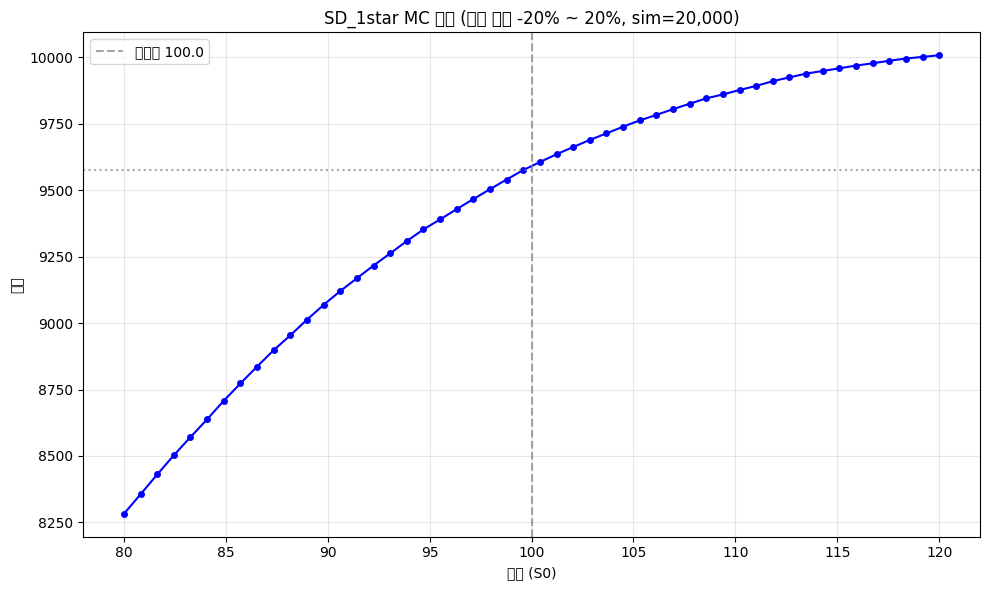

주가 범위 -20% ~ 20% (기준가 100)
S0(주가) | 가격
------------------------
    80.0 | 8,282
    80.8 | 8,356
    81.6 | 8,430
    82.4 | 8,503
    83.3 | 8,571
    84.1 | 8,638
    84.9 | 8,708
    85.7 | 8,773
    86.5 | 8,836
    87.3 | 8,898
    88.2 | 8,954
    89.0 | 9,013
    89.8 | 9,069
    90.6 | 9,121
    91.4 | 9,169
    92.2 | 9,217
    93.1 | 9,262
    93.9 | 9,309
    94.7 | 9,353
    95.5 | 9,390
    96.3 | 9,429
    97.1 | 9,467
    98.0 | 9,504
    98.8 | 9,541
    99.6 | 9,576
   100.4 | 9,606
   101.2 | 9,636
   102.0 | 9,663
   102.9 | 9,689
   103.7 | 9,714
   104.5 | 9,739
   105.3 | 9,763
   106.1 | 9,784
   106.9 | 9,805
   107.8 | 9,826
   108.6 | 9,846
   109.4 | 9,861
   110.2 | 9,877
   111.0 | 9,893
   111.8 | 9,911
   112.7 | 9,925
   113.5 | 9,939
   114.3 | 9,949
   115.1 | 9,959
   115.9 | 9,969
   116.7 | 9,978
   117.6 | 9,987
   118.4 | 9,996
   119.2 | 10,002
   120.0 | 10,008
------------------------
기준가 가격: 9,576


In [25]:
res = SD_1star_MC_graph(
    range_low_pct=-20,
    range_high_pct=20,
    kijun=100.0,
    n_points=50,
    sim=20_000,
    plot=True,
    use_crn=True,
)

print("주가 범위 -20% ~ 20% (기준가 100)")
print("S0(주가) | 가격")
print("-" * 24)
for s, p in zip(res["S0_arr"], res["price_arr"]):
    print(f"  {s:6.1f} | {p:,.0f}")
print("-" * 24)
print(f"기준가 가격: {res['center_price']:,.0f}")

In [6]:
"""
SD_1star (1자산) StepDown ELS 내재변동성 (Implied Volatility)

가격이 주어졌을 때 SD_1star_MC를 이용해 해당 가격에 맞는 변동성을 역산.
"""

import numpy as np
from scipy.optimize import brentq

def SD_1star_MC_imvol(
    target_price,
    S0,
    kijun,
    K,
    T,
    c,
    r,
    q,
    barrier,
    dummy,
    sim=50000,
    seed=111,
    antithetic=True,
    notional=10000.0,
    sigma_lo=0.001,
    sigma_hi=3.0,
    xtol=1e-6,
    maxiter=100,
):
    """
    SD_1star ELS 가격에 대응하는 내재변동성(σ) 역산.

    Parameters
    ----------
    target_price : float
        목표 가격 (내재변동성으로 역산할 시장가격)
    S0 : float
        현 주가
    kijun : float
        기준가
    K : array-like
        조기상환 배리어 비율 (예: [0.9, 0.85, 0.8, ...])
    T : array-like
        조기상환/만기 일수 (예: [365, 730, 1095, ...])
    c : array-like
        조기상환 쿠폰 (예: [0.04, 0.08, 0.12, ...])
    r : float
        무위험 이자율
    q : float
        배당 수익률
    barrier : float
        낙인 배리어 (예: 0.5)
    dummy : float
        만기 무낙인 시 쿠폰
    sim : int
        MC 시뮬레이션 경로 수
    seed : int
        난수 시드
    antithetic : bool
        대조변량 사용 여부
    notional : float
        원금
    sigma_lo, sigma_hi : float
        변동성 탐색 구간 [sigma_lo, sigma_hi]
    xtol : float
        수렴 허용오차 (σ)
    maxiter : int
        최대 반복 횟수

    Returns
    -------
    sigma_iv : float
        내재변동성 (년 단위, 예: 0.18 → 18%)

    Raises
    ------
    ValueError
        sigma_lo~sigma_hi 구간에서 해를 찾지 못한 경우
    """
    K = np.atleast_1d(np.asarray(K, dtype=float))
    T = np.atleast_1d(np.asarray(T, dtype=int))
    c = np.atleast_1d(np.asarray(c, dtype=float))

    def price_diff(sigma):
        p = SD_1star_MC(
            S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
            sim=sim, seed=seed, antithetic=antithetic,
            notional=notional
        )
        return p - target_price

    f_lo = price_diff(sigma_lo)
    f_hi = price_diff(sigma_hi)

    if f_lo * f_hi > 0:
        # 구간 내 해 없음: 최소제곱으로 근사
        from scipy.optimize import minimize_scalar

        def obj(sigma):
            return (price_diff(sigma)) ** 2

        res = minimize_scalar(
            obj, bounds=(sigma_lo, sigma_hi), method="bounded",
            options={"xatol": xtol}
        )
        if res.fun > (target_price * 0.01) ** 2:
            raise ValueError(
                f"내재변동성 수렴 실패: target_price={target_price}, "
                f"sigma_lo={sigma_lo}, sigma_hi={sigma_hi} 구간에서 "
                f"해를 찾지 못함. min residual^2={res.fun:.2e}"
            )
        return float(res.x)

    sigma_iv = brentq(
        price_diff, sigma_lo, sigma_hi,
        xtol=xtol, maxiter=maxiter
    )
    return float(sigma_iv)

In [7]:
SD_1star_MC_imvol(
    9900,
    S0,
    kijun,
    K,
    T,
    c,
    r,
    q,
    barrier,
    dummy,
    sim=50000,
    seed=111,
    antithetic=True,
    notional=10000.0,
    sigma_lo=0.001,
    sigma_hi=3.0,
    xtol=1e-6,
    maxiter=100,
)

0.15583237395379831

# Step Down 2 stock

In [14]:
# -*- coding: utf-8 -*-
"""
2자산(worst-of) StepDown ELS Monte Carlo
backend.get_backend() 기반으로 GPU/CPU 자동 선택

- SD_2star_MC: 통합 함수 (CRN 지원 포함)
- SD_2star_MC_CPU, SD_2star_GPU_CRN: 하위호환용 별칭
"""

import numpy as np

def SD_2star_MC(
    S, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
    sim, seed=111, antithetic=True,
    Z=None, return_Z=False,
    notional=10000.0, dtype="float64"
):
    """
    2자산(worst-of) StepDown ELS Monte Carlo (GPU/CPU 통합)

    Parameters
    ----------
    Z : array or None
        None이면 내부에서 표준정규 Z 생성 (seed/antithetic 적용)
        Z shape: (N, sim, 2) where N = T[-1]
        Z를 넘기면 해당 Z 사용 (CRN). backend와 동일한 라이브러리여야 함.
    return_Z : bool
        True이면 (mu, Z) 반환

    Returns
    -------
    mu : float
    (mu, Z) if return_Z=True
    """
    xp = get_backend()
    dtype_xp = xp.float64 if dtype == "float64" else xp.float32

    # ---------- 입력 정리 (인덱싱용은 numpy, 대용량은 xp) ----------
    T_np = np.atleast_1d(np.asarray(T, dtype=int))
    K_np = np.atleast_1d(np.asarray(K, dtype=float))
    c_np = np.atleast_1d(np.asarray(c, dtype=float))

    S_arr = xp.asarray(S, dtype=dtype_xp).reshape(2)
    kijun_arr = xp.asarray(kijun, dtype=dtype_xp).reshape(2)
    sigma_arr = xp.asarray(sigma, dtype=dtype_xp).reshape(2)
    q_arr = xp.asarray(q, dtype=dtype_xp).reshape(2)

    K_arr = xp.asarray(K_np, dtype=dtype_xp)
    c_arr = xp.asarray(c_np, dtype=dtype_xp)

    EN = len(T_np)
    if not (len(K_np) == EN and len(c_np) == EN):
        raise ValueError("K, T, c의 길이는 같아야 합니다. (EN회차)")

    dt = dtype_xp(1.0 / 365.0)

    # ---------- Z 준비 (CRN) ----------
    if Z is None:
        N = int(T_np[-1])
        if N <= 0:
            raise ValueError("T[-1] (만기일)은 양의 정수(일)여야 합니다.")

        xp.random.seed(seed)

        if antithetic:
            half = (sim + 1) // 2
            Z_half = xp.random.standard_normal((N, half, 2))
            Z = xp.concatenate([Z_half, -Z_half], axis=1)[:, :sim, :]
        else:
            Z = xp.random.standard_normal((N, sim, 2))
    else:
        Z = xp.asarray(Z).astype(dtype_xp, copy=False)
        if not (hasattr(Z, "shape") and len(Z.shape) == 3 and Z.shape[2] == 2):
            raise ValueError("Z는 (N, sim, 2) 형태여야 합니다.")
        N, sim_Z, _ = Z.shape
        sim = int(sim_Z)

        if int(T_np[-1]) > N:
            raise ValueError(f"T[-1]={int(T_np[-1])}가 Z의 N={N}보다 큽니다.")

    # ---------- 상관 부여: W = Z @ L.T ----------
    Corr = xp.array([[1.0, rho], [rho, 1.0]], dtype=dtype_xp)
    L = xp.linalg.cholesky(Corr)
    W = Z @ L.T
    W1 = W[:, :, 0]
    W2 = W[:, :, 1]

    # ---------- GBM 경로 ----------
    drift1 = (r - q_arr[0] - 0.5 * sigma_arr[0]**2) * dt
    drift2 = (r - q_arr[1] - 0.5 * sigma_arr[1]**2) * dt
    vol1 = sigma_arr[0] * xp.sqrt(dt)
    vol2 = sigma_arr[1] * xp.sqrt(dt)

    lnS1 = drift1 + vol1 * W1
    lnS2 = drift2 + vol2 * W2

    lnS1 = xp.concatenate([xp.full((1, sim), xp.log(S_arr[0]), dtype=dtype_xp), lnS1], axis=0)
    lnS2 = xp.concatenate([xp.full((1, sim), xp.log(S_arr[1]), dtype=dtype_xp), lnS2], axis=0)

    S1 = xp.exp(xp.cumsum(lnS1, axis=0))
    S2 = xp.exp(xp.cumsum(lnS2, axis=0))

    # ---------- worst-of ratio ----------
    ratio1 = S1 / kijun_arr[0]
    ratio2 = S2 / kijun_arr[1]
    R = xp.minimum(ratio1, ratio2)

    # ---------- 조기상환 ----------
    Price = xp.zeros(sim, dtype=dtype_xp)

    for i in range(EN - 1):
        t = int(T_np[i])
        alive = (Price == 0.0)
        hit = alive & (R[t, :] >= K_arr[i])
        Price = xp.where(
            hit,
            dtype_xp(notional) * (dtype_xp(1.0) + c_arr[i]) * xp.exp(-r * t / 365.0),
            Price
        )

    # ---------- 만기상환 ----------
    alive = (Price == 0.0)
    if xp.any(alive):
        R_alive = R[:, alive]
        ki_hit = (xp.min(R_alive, axis=0) < barrier)

        t_mat = int(T_np[-1])
        payoff_ki = dtype_xp(notional) * R_alive[t_mat, :] * xp.exp(-r * t_mat / 365.0)
        payoff_no = dtype_xp(notional) * (dtype_xp(1.0) + dtype_xp(dummy)) * xp.exp(-r * t_mat / 365.0)

        Price_alive = xp.where(ki_hit, payoff_ki, payoff_no)
        Price[alive] = Price_alive

    mu = _to_float(xp.mean(Price))

    if return_Z:
        return mu, Z
    return mu

In [15]:
# 스텝다운 상품 평가 정보 (2-stock 예시)
S0 = [100, 100] # 기초자산 종가
kijun = [100, 95] # 기준주가(발행일 주가)
r = 0.035 # 이자율
q = [0,0] # 배당율
sigma = [0.3, 0.5] # 변동성
rho = 0.6 # 상관계수

barrier = 0.65 # Knock In Barrier
dummy = 0.2 # dummy coupon
sim = 10000 # 시뮬레이션 회수

K = [0.95, 0.95, 0.95, 0.90, 0.85, 0.80] # 행사가
T=np.array([ 181,  365,  546,  730,  912, 1098])

c = np.array([1, 2, 3, 4, 5, 6]) * 0.10 # ELS쿠폰

SD_2star_MC(S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy, sim)

8900.423199450874

In [16]:
!apt-get install -y fonts-nanum -qq

Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1) 폰트 파일 경로 (존재하는 걸로 확인됨)
FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 2) Matplotlib 폰트 매니저에 "등록" (중요)
fm.fontManager.addfont(FONT_PATH)

# 3) 등록된 폰트의 정확한 패밀리 이름을 파일에서 다시 읽어옴
font_name = fm.FontProperties(fname=FONT_PATH).get_name()
print("Resolved font_name:", font_name)

# 4) rcParams 리셋 후 적용
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

Resolved font_name: NanumGothic


In [ ]:
# MC 코드 수렴성 보기

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 공통 파라미터
# -----------------------------
S0 = [100, 100] # 기초자산 종가
kijun = [100, 95] # 기준주가(발행일 주가)
r = 0.035 # 이자율
q = [0,0] # 배당율
sigma = [0.3, 0.5] # 변동성
rho = 0.6 # 상관계수

barrier = 0.65 # Knock In Barrier
dummy = 0.2 # dummy coupon
sim = 10000 # 시뮬레이션 회수

K = [0.95, 0.95, 0.95, 0.90, 0.85, 0.80] # 행사가
T=np.array([ 181,  365,  546,  730,  912, 1098])
c = np.array([1, 2, 3, 4, 5, 6]) * 0.10 # ELS쿠폰
notional = 10000.0

SIM_COUNTS = [1_000, 2_000, 5_000, 10_000, 20_000,50_000,100_000,200_000]
N_SEEDS = 3
BASE_SEED = 111

means = []
stds = []
sems = []

for sim in SIM_COUNTS:
    prices = []
    print(f"running sim={sim} ...")   # 진행상황 확인용

    for i in range(N_SEEDS):
        seed = BASE_SEED + i * 1000

        p = SD_2star_MC(
            S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
            sim=sim, seed=seed, antithetic=True, notional=notional
        )
        prices.append(float(p))

    arr = np.array(prices, dtype=float)

    mean_val = np.mean(arr)
    std_val = np.std(arr, ddof=1) if len(arr) > 1 else 0.0
    sem_val = std_val / np.sqrt(len(arr)) if len(arr) > 0 else 0.0

    means.append(mean_val)
    stds.append(std_val)
    sems.append(sem_val)

means = np.array(means)
sems = np.array(sems)

print("means =", means)
print("sems  =", sems)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 상단
ci95 = 1.96 * sems
axes[0].errorbar(
    SIM_COUNTS, means, yerr=ci95,
    fmt="o-", capsize=4, linewidth=2, markersize=6
)
axes[0].axhline(means[-1], linestyle="--", alpha=0.7)
axes[0].set_xscale("log")
axes[0].set_ylabel("가격")
axes[0].set_title("MC 가격 수렴")
axes[0].grid(True, alpha=0.3)

# 하단
axes[1].semilogx(SIM_COUNTS, sems, "s-", linewidth=2, markersize=6)
axes[1].set_xlabel("시뮬레이션 회수")
axes[1].set_ylabel("SEM")
axes[1].set_title("표준오차 감소")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


running sim=1000 ...
running sim=2000 ...
running sim=5000 ...
running sim=10000 ...
running sim=20000 ...
running sim=50000 ...
running sim=100000 ...
running sim=200000 ...


In [ ]:
def MC_Greeks_SD2_GPU_CRN(
    S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
    sim, seed=111, antithetic=True,
    notional=10000.0, dtype="float64",
    pricer=None,
    bump_S_frac=0.01,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
):
    """
    2자산(worst-of) StepDown ELS MC Greeks (GPU/CPU 통합)
    SD_2star_MC를 pricer로 사용. CRN으로 수치 미분.
    """
    if pricer is None:
        pricer = SD_2star_MC

    # ---- 입력 정리 ----
    S0 = np.asarray(S0, dtype=float).reshape(2,)
    kijun = np.asarray(kijun, dtype=float).reshape(2,)

    q = np.asarray(q, dtype=float).reshape(2,)
    sigma = np.asarray(sigma, dtype=float).reshape(2,)

    T = np.atleast_1d(np.asarray(T, dtype=int))
    K = np.atleast_1d(np.asarray(K, dtype=float))
    c = np.atleast_1d(np.asarray(c, dtype=float))

    if not (len(T) == len(K) == len(c)):
        raise ValueError("K, T, c 길이는 같아야 합니다.")

    # ---- 0) CRN용 Z 1회 생성 + base price ----
    C0, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
        sim=sim, seed=seed, antithetic=antithetic,
        Z=None, return_Z=True, notional=notional, dtype=dtype
    )

    # ======================================================
    # 1) Delta / Gamma (각 자산별)
    # ======================================================
    Delta = np.zeros(2, dtype=float)
    Gamma = np.zeros(2, dtype=float)

    for j in range(2):
        eps_Sj = S0[j] * sigma[j] * bump_S_frac
        eps_Sj = max(eps_Sj, 1e-12)

        S_up = S0.copy();   S_up[j] += eps_Sj
        S_dn = S0.copy();   S_dn[j] -= eps_Sj

        Cp = pricer(
            S_up, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
            sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
        )
        Cm = pricer(
            S_dn, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
            sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
        )

        Delta[j] = (Cp - Cm) / (2.0 * eps_Sj)
        Gamma[j] = (Cp - 2.0 * C0 + Cm) / (eps_Sj ** 2)

    # (선택) Cross-Gamma: d2C/dS1dS2 (혼합 2차 미분)
    eps_S1 = max(S0[0] * sigma[0] * bump_S_frac, 1e-12)
    eps_S2 = max(S0[1] * sigma[1] * bump_S_frac, 1e-12)

    S_pp = S0 + np.array([+eps_S1, +eps_S2])
    S_pm = S0 + np.array([+eps_S1, -eps_S2])
    S_mp = S0 + np.array([-eps_S1, +eps_S2])
    S_mm = S0 + np.array([-eps_S1, -eps_S2])

    C_pp = pricer(S_pp, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
                  sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype)
    C_pm = pricer(S_pm, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
                  sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype)
    C_mp = pricer(S_mp, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
                  sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype)
    C_mm = pricer(S_mm, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
                  sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype)

    CrossGamma = (C_pp - C_pm - C_mp + C_mm) / (4.0 * eps_S1 * eps_S2)

    # ======================================================
    # 2) Vega (각 자산별, 1% Vega)
    # ======================================================
    Vega = np.zeros(2, dtype=float)
    Vega_1pct = np.zeros(2, dtype=float)

    for j in range(2):
        eps_sigj = sigma[j] * bump_sigma_frac
        eps_sigj = max(eps_sigj, 1e-12)

        sig_up = sigma.copy(); sig_up[j] += eps_sigj
        sig_dn = sigma.copy(); sig_dn[j] = max(sigma[j] - eps_sigj, 1e-8)

        Csig_p = pricer(
            S0, kijun, K, T, c, r, q, sig_up, rho, barrier, dummy,
            sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
        )
        Csig_m = pricer(
            S0, kijun, K, T, c, r, q, sig_dn, rho, barrier, dummy,
            sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
        )

        Vega[j] = (Csig_p - Csig_m) / (2.0 * eps_sigj)
        Vega_1pct[j] = 0.01 * Vega[j]

    # ======================================================
    # 3) Theta (1-day): 모든 관측일 1일 당김
    # ======================================================
    Tm = np.maximum(T - 1, 0)

    Ct = pricer(
        S0, kijun, K, Tm, c, r, q, sigma, rho, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Theta_1d = Ct - C0

    # ======================================================
    # 4) Rho (1bp)
    # ======================================================
    eps_r = bump_r_bp * 0.0001

    Cr_p = pricer(
        S0, kijun, K, T, c, r + eps_r, q, sigma, rho, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cr_m = pricer(
        S0, kijun, K, T, c, r - eps_r, q, sigma, rho, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Rho_per_unit = (Cr_p - Cr_m) / (2.0 * eps_r)
    Rho_1bp = 0.0001 * Rho_per_unit

    return {
        "Price": C0,
        "Delta": Delta,              # shape (2,)
        "Gamma": Gamma,              # shape (2,)
        "CrossGamma": CrossGamma,    # scalar
        "Vega(1%)": Vega_1pct,       # shape (2,)
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
        "bump": {
            "eps_S": [eps_S1, eps_S2],
            "eps_sigma": list(np.maximum(sigma * bump_sigma_frac, 1e-12)),
            "eps_r": eps_r,
            "CRN": True,
            "antithetic": antithetic,
            "seed": seed,
        }
    }


# 하위호환
MC_Greeks_SD2_CRN = MC_Greeks_SD2_GPU_CRN

In [ ]:
# 발행일
out=MC_Greeks_SD2_GPU_CRN(
    S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
    sim, seed=111, antithetic=True,
    notional=10000.0, dtype="float64",
    pricer=None,
    bump_S_frac=0.01,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
)
out

In [ ]:
"""
SD_2star (2자산 worst-of) StepDown ELS FDM 프라이싱
Operator Splitting Method (ADI) 사용

SD_2star_GPU_CRN (Monte Carlo)과 동일한 상품 구조:
- R = min(S1/k1, S2/k2) = worst-of ratio
- 조기상환: T[i]에 R >= K[i] 이면 notional*(1+c[i])
- 만기: min(R) < barrier 이면 낙인 → notional*R_T, else notional*(1+dummy)
"""

import numpy as np

try:
    from scipy import sparse
    from scipy.sparse.linalg import spsolve
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False


def _tridiag_solve(low, diag, up, rhs):
    """Thomas algorithm for tridiagonal system."""
    n = len(diag)
    cp, dp = np.zeros(n), np.zeros(n)
    cp[0] = up[0] / diag[0]
    dp[0] = rhs[0] / diag[0]
    for i in range(1, n - 1):
        denom = diag[i] - low[i - 1] * cp[i - 1]
        cp[i] = up[i] / denom
        dp[i] = (rhs[i] - low[i - 1] * dp[i - 1]) / denom
    denom = diag[-1] - low[-1] * cp[-2]
    dp[-1] = (rhs[-1] - low[-1] * dp[-2]) / denom
    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n - 2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i + 1]
    return x


def _apply_1d_implicit_x1(V, dt, dx1, mu1, sig1, r, nx1, nx2):
    """x1 방향 implicit step: (I - dt*L1) V_new = V"""
    a1 = 0.5 * sig1**2
    c1 = mu1 - 0.5 * sig1**2
    for j2 in range(nx2):
        rhs = V[:, j2].copy()
        low = np.zeros(nx1 - 1)
        diag = np.ones(nx1)
        up = np.zeros(nx1 - 1)
        for i in range(1, nx1 - 1):
            low[i-1] = -dt * (-c1/(2*dx1) + a1/(dx1**2))
            diag[i] = 1 - dt * (-2*a1/(dx1**2) - r)
            up[i] = -dt * (c1/(2*dx1) + a1/(dx1**2))
        diag[0] = diag[-1] = 1.0
        up[0] = low[-1] = 0.0
        if _HAS_SCIPY:
            L = sparse.diags([low, diag, up], [-1, 0, 1], format="csc")
            V[:, j2] = spsolve(L, rhs)
        else:
            V[:, j2] = _tridiag_solve(low, diag, up, rhs)
    return V


def _apply_1d_implicit_x2(V, dt, dx2, mu2, sig2, r, nx1, nx2):
    """x2 방향 implicit step: (I - dt*L2) V_new = V"""
    a2 = 0.5 * sig2**2
    c2 = mu2 - 0.5 * sig2**2
    for j1 in range(nx1):
        rhs = V[j1, :].copy()
        low = np.zeros(nx2 - 1)
        diag = np.ones(nx2)
        up = np.zeros(nx2 - 1)
        for i in range(1, nx2 - 1):
            low[i-1] = -dt * (-c2/(2*dx2) + a2/(dx2**2))
            diag[i] = 1 - dt * (-2*a2/(dx2**2) - r)
            up[i] = -dt * (c2/(2*dx2) + a2/(dx2**2))
        diag[0] = diag[-1] = 1.0
        up[0] = low[-1] = 0.0
        if _HAS_SCIPY:
            L = sparse.diags([low, diag, up], [-1, 0, 1], format="csc")
            V[j1, :] = spsolve(L, rhs)
        else:
            V[j1, :] = _tridiag_solve(low, diag, up, rhs)
    return V


def _apply_mixed_explicit(V, dt, rho, sig1, sig2, dx1, dx2, nx1, nx2):
    """Mixed derivative: L12 = rho*sig1*sig2 * d2V/dx1dx2, explicit"""
    coef = rho * sig1 * sig2 * dt / (4 * dx1 * dx2)
    V_new = V.copy()
    for i in range(1, nx1 - 1):
        for j in range(1, nx2 - 1):
            V_new[i, j] += coef * (
                V[i+1, j+1] - V[i+1, j-1] - V[i-1, j+1] + V[i-1, j-1]
            )
    return V_new


def _solve_2d_pde_adi(V, dt, n_steps, r, q1, q2, sig1, sig2, rho, dx1, dx2):
    """
    2D Black-Scholes PDE in (x1, x2) = (ln R1, ln R2)
    Operator Splitting (Douglas-Rachford type ADI):
    - Step 1: (I - dt*L1) V* = V + dt*L12*V  (mixed explicit)
    - Step 2: (I - dt*L2) V_new = V*
    """
    nx1, nx2 = V.shape
    mu1 = r - q1
    mu2 = r - q2

    for _ in range(n_steps):
        # Mixed derivative (explicit)
        V_rhs = _apply_mixed_explicit(V, dt, rho, sig1, sig2, dx1, dx2, nx1, nx2)
        # ADI: x1 then x2
        V = _apply_1d_implicit_x1(V_rhs.copy(), dt, dx1, mu1, sig1, r, nx1, nx2)
        V = _apply_1d_implicit_x2(V, dt, dx2, mu2, sig2, r, nx1, nx2)

    return V


def SD_2star_FDM(
    S, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
    nR=41, nm=31, n_steps_per_day=2,
    notional=10000.0,
    return_grid=False,
):
    """
    SD_2star (2자산 worst-of) ELS FDM - Operator Splitting

    Parameters
    ----------
    S : [S1, S2]
    kijun : [k1, k2]
    K, T, c : 조기상환 조건
    r, q : [q1, q2] or scalar
    sigma : [σ1, σ2]
    rho : 상관계수
    barrier, dummy, notional
    return_grid : bool
        True이면 (price, grid) 반환 (FDM_Greeks 그리드 기반용)
    """
    S_np = np.asarray(S, dtype=float).reshape(2)
    kijun_np = np.asarray(kijun, dtype=float).reshape(2)
    sigma_np = np.asarray(sigma, dtype=float).reshape(2)
    q_np = np.asarray(q, dtype=float).reshape(2)
    T_np = np.atleast_1d(np.asarray(T, dtype=float))
    K_np = np.atleast_1d(np.asarray(K, dtype=float))
    c_np = np.atleast_1d(np.asarray(c, dtype=float))

    if not (len(K_np) == len(T_np) == len(c_np)):
        raise ValueError("K, T, c 길이 불일치")

    q1, q2 = float(q_np[0]), float(q_np[1])
    sig1, sig2 = float(sigma_np[0]), float(sigma_np[1])
    R1_0 = S_np[0] / kijun_np[0]
    R2_0 = S_np[1] / kijun_np[1]
    t_obs = T_np

    # (x1, x2) = (ln R1, ln R2) 그리드
    R_min, R_max = 0.15, 3.0
    ln_min, ln_max = np.log(R_min), np.log(R_max)
    x1 = np.linspace(ln_min, ln_max, nR)
    x2 = np.linspace(ln_min, ln_max, nR)
    R1 = np.exp(x1)
    R2 = np.exp(x2)
    dx1 = x1[1] - x1[0]
    dx2 = x2[1] - x2[0]

    # m = running min of min(R1,R2)
    m_min = min(R_min, barrier * 0.5)
    m_max = R_max
    m = np.linspace(m_min, m_max, nm)

    # 3D: V[x1_idx, x2_idx, m_idx], m <= min(R1,R2)
    V = np.zeros((nR, nR, nm))

    # 만기 페이오프: R = min(R1,R2)
    for i1 in range(nR):
        for i2 in range(nR):
            R = min(R1[i1], R2[i2])
            for k in range(nm):
                if m[k] < barrier:
                    V[i1, i2, k] = notional * R
                else:
                    V[i1, i2, k] = notional * (1.0 + dummy)

    EN = len(t_obs)

    for i in range(EN - 2, -1, -1):
        t_cur = t_obs[i]
        t_next = t_obs[i + 1]
        n_days = int(t_next - t_cur)
        n_steps = max(2, min(n_days * n_steps_per_day, 50))  # cap for speed
        dt = (t_next - t_cur) / 365.0 / n_steps

        # PDE backward for each m slice
        for k in range(nm):
            V[:, :, k] = _solve_2d_pde_adi(
                V[:, :, k].copy(), dt, n_steps,
                r, q1, q2, sig1, sig2, rho, dx1, dx2
            )

        # 관찰일: 조기상환 + m 갱신
        K_i = K_np[i]
        c_i = c_np[i]
        early_pay = notional * (1.0 + c_i)
        V_new = np.zeros_like(V)

        for i1 in range(nR):
            for i2 in range(nR):
                R = min(R1[i1], R2[i2])
                if R >= K_i:
                    V_new[i1, i2, :] = early_pay
                else:
                    m_new = np.minimum(m, R)
                    for k in range(nm):
                        mn = m_new[k]
                        if mn <= m[0]:
                            V_new[i1, i2, k] = V[i1, i2, 0]
                        elif mn >= m[-1]:
                            V_new[i1, i2, k] = V[i1, i2, -1]
                        else:
                            idx = np.searchsorted(m, mn)
                            w = (mn - m[idx - 1]) / (m[idx] - m[idx - 1])
                            V_new[i1, i2, k] = (1 - w) * V[i1, i2, idx - 1] + w * V[i1, i2, idx]
        V = V_new.copy()

    # t=0까지 PDE
    n_days_0 = int(t_obs[0])
    n_steps_0 = max(2, min(n_days_0 * n_steps_per_day, 50))
    dt_0 = t_obs[0] / 365.0 / n_steps_0
    for k in range(nm):
        V[:, :, k] = _solve_2d_pde_adi(
            V[:, :, k].copy(), dt_0, n_steps_0,
            r, q1, q2, sig1, sig2, rho, dx1, dx2
        )

    # 초기 (R1_0, R2_0, m0=R0) 보간
    R0 = min(R1_0, R2_0)
    x1_0, x2_0 = np.log(R1_0), np.log(R2_0)
    m0 = R0

    def interp_3d(V, x1v, x2v, mv):
        i1 = np.clip(np.searchsorted(x1, x1v), 1, nR - 1)
        i2 = np.clip(np.searchsorted(x2, x2v), 1, nR - 1)
        km = np.clip(np.searchsorted(m, mv), 1, nm - 1)
        x1v = np.clip(x1v, x1[0], x1[-1])
        x2v = np.clip(x2v, x2[0], x2[-1])
        mv = np.clip(mv, m[0], m[-1])
        wx1 = (x1v - x1[i1 - 1]) / (x1[i1] - x1[i1 - 1]) if x1[i1] != x1[i1 - 1] else 0
        wx2 = (x2v - x2[i2 - 1]) / (x2[i2] - x2[i2 - 1]) if x2[i2] != x2[i2 - 1] else 0
        wm = (mv - m[km - 1]) / (m[km] - m[km - 1]) if m[km] != m[km - 1] else 0
        wx1 = np.clip(wx1, 0, 1)
        wx2 = np.clip(wx2, 0, 1)
        wm = np.clip(wm, 0, 1)
        p000 = V[i1 - 1, i2 - 1, km - 1]
        p100 = V[i1, i2 - 1, km - 1]
        p010 = V[i1 - 1, i2, km - 1]
        p110 = V[i1, i2, km - 1]
        p001 = V[i1 - 1, i2 - 1, km]
        p101 = V[i1, i2 - 1, km]
        p011 = V[i1 - 1, i2, km]
        p111 = V[i1, i2, km]
        return ((1 - wx1) * (1 - wx2) * (1 - wm) * p000 +
                wx1 * (1 - wx2) * (1 - wm) * p100 +
                (1 - wx1) * wx2 * (1 - wm) * p010 +
                wx1 * wx2 * (1 - wm) * p110 +
                (1 - wx1) * (1 - wx2) * wm * p001 +
                wx1 * (1 - wx2) * wm * p101 +
                (1 - wx1) * wx2 * wm * p011 +
                wx1 * wx2 * wm * p111)

    price = interp_3d(V, x1_0, x2_0, m0)

    if return_grid:
        # 보간용 인덱스/가중치
        i1 = np.clip(np.searchsorted(x1, x1_0), 1, nR - 1)
        i2 = np.clip(np.searchsorted(x2, x2_0), 1, nR - 1)
        km = np.clip(np.searchsorted(m, m0), 1, nm - 1)
        x1c = np.clip(x1_0, x1[0], x1[-1])
        x2c = np.clip(x2_0, x2[0], x2[-1])
        mc = np.clip(m0, m[0], m[-1])
        wx1 = (x1c - x1[i1 - 1]) / (x1[i1] - x1[i1 - 1]) if x1[i1] != x1[i1 - 1] else 0
        wx2 = (x2c - x2[i2 - 1]) / (x2[i2] - x2[i2 - 1]) if x2[i2] != x2[i2 - 1] else 0
        wm = (mc - m[km - 1]) / (m[km] - m[km - 1]) if m[km] != m[km - 1] else 0
        wx1, wx2, wm = np.clip(wx1, 0, 1), np.clip(wx2, 0, 1), np.clip(wm, 0, 1)
        grid = {
            "V": V, "x1": x1, "x2": x2, "R1": R1, "R2": R2, "m": m,
            "x1_0": x1_0, "x2_0": x2_0, "m0": m0, "R1_0": R1_0, "R2_0": R2_0,
            "i1": i1, "i2": i2, "km": km, "wx1": wx1, "wx2": wx2, "wm": wm,
            "r": r, "q1": q1, "q2": q2, "sig1": sig1, "sig2": sig2, "rho": rho,
            "kijun": kijun_np, "dx1": dx1, "dx2": dx2, "nR": nR, "nm": nm,
        }
        return float(price), grid
    return float(price)

In [ ]:
SD_2star_FDM(
    S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
    nR=41, nm=31, n_steps_per_day=1,
    notional=10000.0,
)

In [ ]:
"""
SD_2star FDM vs MC 가격 검증 (Colab / 함수가 이미 셀에 정의된 경우)
- MC 시뮬레이션 수 증가에 따른 수렴
- FDM 그리드 정밀도 증가에 따른 수렴
- 두 방법 간 차이 분석
"""

import numpy as np

def main():
    # -----------------------------
    # 공통 파라미터
    # -----------------------------
    S0 = [100, 100] # 기초자산 종가
    kijun = [100, 95] # 기준주가(발행일 주가)
    r = 0.035 # 이자율
    q = [0,0] # 배당율
    sigma = [0.3, 0.5] # 변동성
    rho = 0.6 # 상관계수

    barrier = 0.65 # Knock In Barrier
    dummy = 0.2 # dummy coupon
    sim = 10000 # 시뮬레이션 회수

    K = [0.95, 0.95, 0.95, 0.90, 0.85, 0.80] # 행사가
    T=np.array([ 181,  365,  546,  730,  912, 1098])
    c = np.array([1, 2, 3, 4, 5, 6]) * 0.10 # ELS쿠폰
    notional = 10000.0

    print("=" * 60)
    print("SD_2star (2자산 worst-of) FDM vs MC 가격 검증")
    print("=" * 60)
    print("파라미터: S=100, kijun=100, rho=0.5")
    print("         barrier=0.55, 5회차 StepDown")
    print()

    # ---- 0) 함수 존재 확인 ----
    print("--- 0) 함수 존재 확인 ---")
    print("SD_2star_MC  :", callable(SD_2star_MC))
    print("SD_2star_FDM :", callable(SD_2star_FDM))
    print()

    # ---- 1) MC 수렴 테스트 (sim 증가) ----
    print("--- 1) MC 수렴 (sim 증가) ---")
    seeds = [111, 222, 333]
    for sim in [10_000, 50_000, 100_000, 200_000, 500_000]:
        prices = []
        for seed in seeds:
            p = SD_2star_MC(
                S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
                sim=sim, seed=seed, antithetic=True, notional=notional
            )
            prices.append(float(p))

        mu = np.mean(prices)
        std = np.std(prices, ddof=1) if len(prices) > 1 else 0.0
        sem = std / np.sqrt(len(prices)) if len(prices) > 1 else 0.0
        print(f"  sim={sim:>7}: mean={mu:.2f}, std={std:.2f}, sem~={sem:.2f}")

    print()

    # ---- 2) FDM 수렴 테스트 (그리드 정밀도) ----
    print("--- 2) FDM 수렴 (nR, nm, n_steps_per_day) ---")
    for (nR, nm, spd) in [
        (21, 11, 1),
        (31, 15, 1),
        (41, 21, 1),
        (51, 31, 2),
        (61, 41, 2),
    ]:
        p = SD_2star_FDM(
            S, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
            nR=nR, nm=nm, n_steps_per_day=spd, notional=notional
        )
        print(f"  nR={nR}, nm={nm}, spd={spd}: {float(p):.2f}")

    print()

    # ---- 3) 기준 비교 ----
    print("--- 3) 기준 비교 ---")
    price_fdm = float(SD_2star_FDM(
        S, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
        nR=61, nm=41, n_steps_per_day=2, notional=notional
    ))
    price_mc_50k = float(SD_2star_MC(
        S, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
        sim=50_000, seed=111, antithetic=True, notional=notional
    ))
    price_mc_500k = float(SD_2star_MC(
        S, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
        sim=500_000, seed=111, antithetic=True, notional=notional
    ))

    print(f"  FDM (nR=61, nm=41, spd=2): {price_fdm:.2f}")
    print(f"  MC  (50k sim):             {price_mc_50k:.2f}")
    print(f"  MC  (500k sim):            {price_mc_500k:.2f}")
    print()

    diff_50k = price_fdm - price_mc_50k
    diff_500k = price_fdm - price_mc_500k
    print(f"  FDM - MC(50k):  {diff_50k:+.2f} ({100*diff_50k/notional:+.2f}%)")
    print(f"  FDM - MC(500k): {diff_500k:+.2f} ({100*diff_500k/notional:+.2f}%)")
    print()

    # ---- 4) MC 신뢰구간 ----
    print("--- 4) MC 500k 10회 반복 (신뢰구간) ---")
    mc_prices = []
    for seed in range(111, 121):
        p = SD_2star_MC(
            S, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
            sim=500_000, seed=seed, antithetic=True, notional=notional
        )
        mc_prices.append(float(p))

    mc_mean = np.mean(mc_prices)
    mc_std = np.std(mc_prices, ddof=1) if len(mc_prices) > 1 else 0.0
    mc_sem = mc_std / np.sqrt(len(mc_prices)) if len(mc_prices) > 1 else 0.0

    print(f"  MC mean: {mc_mean:.2f} ± {1.96*mc_sem:.2f} (95% CI)")
    print(f"  FDM:     {price_fdm:.2f}")
    print(f"  차이:     {price_fdm - mc_mean:+.2f} ({100*(price_fdm-mc_mean)/notional:+.2f}%)")
    print()

    # ---- 5) 결론 ----
    print("--- 5) 요약 ---")
    rel_diff = 100 * abs(price_fdm - mc_mean) / notional
    if rel_diff < 0.5:
        verdict = f"차이 {rel_diff:.2f}%로 양호"
    elif rel_diff < 1.0:
        verdict = f"차이 {rel_diff:.2f}%로 약간 있음 (FDM grid/discretization 또는 MC variance 고려)"
    else:
        verdict = f"차이 {rel_diff:.2f}%로 유의. FDM/상품 구조 재검토 필요"
    print(f"  {verdict}")
    print()

main()

In [ ]:
def _greeks_from_grid_2d(grid):
    """
    3D 그리드(V[x1,x2,m])에서 Delta, Gamma, CrossGamma, Theta 산출.
    x1=ln R1, x2=ln R2, S1=k1*R1 → dV/dS1 = dV/dx1 / (R1*k1)
    2D BS: Theta = -[(r-q1)R1 dV/dR1 + (r-q2)R2 dV/dR2 + 0.5σ1²R1²d²V/dR1² + ... - rV]
    """
    V = grid["V"]
    x1, x2, m = grid["x1"], grid["x2"], grid["m"]
    R1_0, R2_0 = grid["R1_0"], grid["R2_0"]
    i1, i2, km = grid["i1"], grid["i2"], grid["km"]
    wx1, wx2, wm = grid["wx1"], grid["wx2"], grid["wm"]
    r, q1, q2, sig1, sig2, rho = grid["r"], grid["q1"], grid["q2"], grid["sig1"], grid["sig2"], grid["rho"]
    k1, k2 = grid["kijun"][0], grid["kijun"][1]
    dx1, dx2 = grid["dx1"], grid["dx2"]
    nR, nm = grid["nR"], grid["nm"]

    def _V_interp_m(i1v, i2v):
        """(i1v, i2v)에서 m 방향 보간"""
        p0 = (1 - wm) * V[i1v, i2v, km - 1] + wm * V[i1v, i2v, km]
        return float(p0)

    def _V_interp_m_at(i1v, i2v):
        """(i1v, i2v)에서 x2,m 보간 (i1 고정)"""
        v00 = (1 - wm) * V[i1v, i2 - 1, km - 1] + wm * V[i1v, i2 - 1, km]
        v01 = (1 - wm) * V[i1v, i2, km - 1] + wm * V[i1v, i2, km]
        return (1 - wx2) * v00 + wx2 * v01

    def _V_interp_m_at_j2(i1v, i2v):
        """(i1v, i2v)에서 m만 보간"""
        return (1 - wm) * V[i1v, i2v, km - 1] + wm * V[i1v, i2v, km]

    # m 보간 후 (i1, i2) 평면에서 값
    v_i1p1 = _V_interp_m_at(i1 + 1, i2) if i1 + 1 < nR else _V_interp_m_at(i1, i2)
    v_i1m1 = _V_interp_m_at(i1 - 1, i2)
    v_i1m2 = _V_interp_m_at(i1 - 2, i2) if i1 >= 2 else v_i1m1
    v_cen   = _V_interp_m_at(i1, i2)

    v_i2p1 = (1 - wx1) * _V_interp_m_at_j2(i1 - 1, i2 + 1) + wx1 * _V_interp_m_at_j2(i1, i2 + 1) if i2 + 1 < nR else v_cen
    v_i2m1 = (1 - wx1) * _V_interp_m_at_j2(i1 - 1, i2 - 1) + wx1 * _V_interp_m_at_j2(i1, i2 - 1)
    v_i2m2 = (1 - wx1) * _V_interp_m_at_j2(i1 - 1, i2 - 2) + wx1 * _V_interp_m_at_j2(i1, i2 - 2) if i2 >= 2 else v_i2m1

    dVdx1 = (v_i1p1 - v_i1m1) / (2 * dx1) if i1 + 1 < nR else (v_cen - v_i1m1) / dx1
    dVdx2 = (v_i2p1 - v_i2m1) / (2 * dx2) if i2 + 1 < nR else (v_cen - v_i2m1) / dx2

    d2Vdx12 = (v_i1p1 - 2 * v_cen + v_i1m1) / (dx1 * dx1) if i1 + 1 < nR else 0.0
    d2Vdx22 = (v_i2p1 - 2 * v_cen + v_i2m1) / (dx2 * dx2) if i2 + 1 < nR else 0.0

    # Cross: d²V/dx1dx2
    v_pp = _V_interp_m_at_j2(i1 + 1, i2 + 1) if i1 + 1 < nR and i2 + 1 < nR else v_cen
    v_pm = _V_interp_m_at_j2(i1 + 1, i2 - 1) if i1 + 1 < nR else v_cen
    v_mp = _V_interp_m_at_j2(i1 - 1, i2 + 1) if i2 + 1 < nR else v_cen
    v_mm = _V_interp_m_at_j2(i1 - 1, i2 - 1)
    d2Vdx1dx2 = (v_pp - v_pm - v_mp + v_mm) / (4 * dx1 * dx2)

    # dV/dR = dV/dx / R, d²V/dR² = (d²V/dx² - dV/dx) / R²
    dVdR1 = dVdx1 / R1_0
    dVdR2 = dVdx2 / R2_0
    d2VdR12 = (d2Vdx12 - dVdx1) / (R1_0 * R1_0)
    d2VdR22 = (d2Vdx22 - dVdx2) / (R2_0 * R2_0)
    d2VdR1dR2 = d2Vdx1dx2 / (R1_0 * R2_0)

    Delta = np.array([dVdR1 / k1, dVdR2 / k2])
    Gamma = np.array([d2VdR12 / (k1 * k1), d2VdR22 / (k2 * k2)])
    CrossGamma = d2VdR1dR2 / (k1 * k2)

    price = float(
        (1 - wx1) * (1 - wx2) * (1 - wm) * V[i1 - 1, i2 - 1, km - 1]
        + wx1 * (1 - wx2) * (1 - wm) * V[i1, i2 - 1, km - 1]
        + (1 - wx1) * wx2 * (1 - wm) * V[i1 - 1, i2, km - 1]
        + wx1 * wx2 * (1 - wm) * V[i1, i2, km - 1]
        + (1 - wx1) * (1 - wx2) * wm * V[i1 - 1, i2 - 1, km]
        + wx1 * (1 - wx2) * wm * V[i1, i2 - 1, km]
        + (1 - wx1) * wx2 * wm * V[i1 - 1, i2, km]
        + wx1 * wx2 * wm * V[i1, i2, km]
    )
    # Theta from 2D BS: dV/dt = -L[V]
    Lv = (
        (r - q1) * R1_0 * dVdR1 + (r - q2) * R2_0 * dVdR2
        + 0.5 * sig1**2 * R1_0**2 * d2VdR12 + 0.5 * sig2**2 * R2_0**2 * d2VdR22
        + rho * sig1 * sig2 * R1_0 * R2_0 * d2VdR1dR2 - r * price
    )
    Theta_1d = -Lv / 365.0

    return price, Delta, Gamma, CrossGamma, Theta_1d


def FDM_Greeks(
    S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
    nR=41, nm=31, n_steps_per_day=1,
    notional=10000.0,
    pricer=None,
    bump_S_frac=0.01,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
):
    """
    SD_2star (2자산 worst-of) StepDown ELS FDM Greeks
    - Delta, Gamma, CrossGamma, Theta: 그리드에서 직접 산출 (추가 solve 0)
    - Vega, Rho: bump 1회씩 (총 3번 solve)
    SD_1star_FDM과 동일한 최소 계산 방식.
    """
    if pricer is None:
        pricer = SD_2star_FDM

    S0 = np.asarray(S0, dtype=float).reshape(2)
    kijun = np.asarray(kijun, dtype=float).reshape(2)
    q = np.asarray(q, dtype=float).reshape(2)
    sigma = np.asarray(sigma, dtype=float).reshape(2)
    T = np.atleast_1d(np.asarray(T, dtype=int))
    K = np.atleast_1d(np.asarray(K, dtype=float))
    c = np.atleast_1d(np.asarray(c, dtype=float))

    def _price(S, sig, rr, tt, nn=notional):
        return pricer(
            S, kijun, K, tt, c, rr, q, sig, rho, barrier, dummy,
            nR=nR, nm=nm, n_steps_per_day=n_steps_per_day, notional=nn
        )

    use_grid = (pricer is SD_2star_FDM)

    if use_grid:
        C0, grid = pricer(
            S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
            nR=nR, nm=nm, n_steps_per_day=n_steps_per_day, notional=notional,
            return_grid=True
        )
        _, Delta, Gamma, CrossGamma, Theta_1d = _greeks_from_grid_2d(grid)
    else:
        C0 = _price(S0, sigma, r, T)

        # Delta / Gamma / CrossGamma (bump)
        Delta = np.zeros(2, dtype=float)
        Gamma = np.zeros(2, dtype=float)
        for j in range(2):
            eps_Sj = max(S0[j] * sigma[j] * bump_S_frac, 1e-12)
            S_up, S_dn = S0.copy(), S0.copy()
            S_up[j], S_dn[j] = S0[j] + eps_Sj, S0[j] - eps_Sj
            Cp = _price(S_up, sigma, r, T)
            Cm = _price(S_dn, sigma, r, T)
            Delta[j] = (Cp - Cm) / (2.0 * eps_Sj)
            Gamma[j] = (Cp - 2.0 * C0 + Cm) / (eps_Sj ** 2)
        eps_S1 = max(S0[0] * sigma[0] * bump_S_frac, 1e-12)
        eps_S2 = max(S0[1] * sigma[1] * bump_S_frac, 1e-12)
        S_pp = S0 + np.array([+eps_S1, +eps_S2])
        S_pm = S0 + np.array([+eps_S1, -eps_S2])
        S_mp = S0 + np.array([-eps_S1, +eps_S2])
        S_mm = S0 + np.array([-eps_S1, -eps_S2])
        CrossGamma = (
            _price(S_pp, sigma, r, T) - _price(S_pm, sigma, r, T)
            - _price(S_mp, sigma, r, T) + _price(S_mm, sigma, r, T)
        ) / (4.0 * eps_S1 * eps_S2)
        Tm = np.maximum(T - 1, 0)
        Theta_1d = _price(S0, sigma, r, Tm) - C0

    # Vega, Rho: bump (SD_1star처럼 one-sided)
    Vega_1pct = np.zeros(2, dtype=float)
    for j in range(2):
        eps_sigj = max(sigma[j] * bump_sigma_frac, 1e-12)
        sig_up = sigma.copy()
        sig_up[j] += eps_sigj
        Vega_per_unit = (_price(S0, sig_up, r, T) - C0) / eps_sigj  # one-sided (SD_1star 스타일)
        Vega_1pct[j] = 0.01 * Vega_per_unit

    eps_r = bump_r_bp * 0.0001
    Rho_per_unit = (_price(S0, sigma, r + eps_r, T) - C0) / eps_r  # one-sided
    Rho_1bp = 0.0001 * Rho_per_unit

    eps_S1 = max(S0[0] * sigma[0] * bump_S_frac, 1e-12)
    eps_S2 = max(S0[1] * sigma[1] * bump_S_frac, 1e-12)

    return {
        "Price": C0,
        "Delta": Delta,
        "Gamma": Gamma,
        "CrossGamma": CrossGamma,
        "Vega(1%)": Vega_1pct,
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
        "bump": {
            "eps_S": [float(eps_S1), float(eps_S2)],
            "eps_sigma": list(np.maximum(sigma * bump_sigma_frac, 1e-12)),
            "eps_r": eps_r,
            "CRN": False,
        }
    }


In [ ]:
FDM_Greeks(
    S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
    nR=41, nm=31, n_steps_per_day=1,
    notional=10000.0,
    pricer=None,
    bump_S_frac=0.01,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
)

In [ ]:
# 발행일
out=MC_Greeks_SD2_GPU_CRN(
    S0, kijun, K, T, c, r, q, sigma, rho, barrier, dummy,
    sim=30000, seed=111, antithetic=True,
    notional=10000.0, dtype="float64",
    pricer=None,
    bump_S_frac=0.01,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
)
out